<a href="https://colab.research.google.com/github/Dajjainia/Telecom---User-Analysis/blob/main/Telecom_Analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import missingno as msno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
import re
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import shap

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/sample data/data_test_uv.CSV'

df = pd.read_csv(file_path)
print("kích thước dữ liệu: ", df.shape)

kích thước dữ liệu:  (200000, 182)


In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,CUOC_GOC_GPRS_210901,CUOC_GOC_GPRS_211001,CUOC_GOC_GPRS_211101,CUOC_GOC_GPRS_211201,CUOC_GOC_GPRS_220101,CUOC_GOC_GPRS_220201,CUOC_GOC_GPRS_220301,CUOC_GOC_GPRS_220401,CUOC_GOC_GPRS_220501,CUOC_GOC_GPRS_220601,HA_TANG_210901,HA_TANG_211001,HA_TANG_211101,HA_TANG_211201,HA_TANG_220101,HA_TANG_220201,HA_TANG_220301,HA_TANG_220401,HA_TANG_220501,HA_TANG_220601,IS_DCOM_210901,IS_DCOM_211001,IS_DCOM_211101,IS_DCOM_211201,IS_DCOM_220101,IS_DCOM_220201,IS_DCOM_220301,IS_DCOM_220401,IS_DCOM_220501,IS_DCOM_220601,IS_SIM_4G_210901,IS_SIM_4G_211001,IS_SIM_4G_211101,IS_SIM_4G_211201,IS_SIM_4G_220101,IS_SIM_4G_220201,IS_SIM_4G_220301,IS_SIM_4G_220401,IS_SIM_4G_220501,IS_SIM_4G_220601,LL_THOAI_210901,LL_THOAI_211001,LL_THOAI_211101,LL_THOAI_211201,LL_THOAI_220101,LL_THOAI_220201,LL_THOAI_220301,LL_THOAI_220401,LL_THOAI_220501,LL_THOAI_220601,NOD_PSLL_DATA_210901,NOD_PSLL_DATA_211001,NOD_PSLL_DATA_211101,NOD_PSLL_DATA_211201,NOD_PSLL_DATA_220101,NOD_PSLL_DATA_220201,NOD_PSLL_DATA_220301,NOD_PSLL_DATA_220401,NOD_PSLL_DATA_220501,NOD_PSLL_DATA_220601,NOD_PSLL_THOAI_210901,NOD_PSLL_THOAI_211001,NOD_PSLL_THOAI_211101,NOD_PSLL_THOAI_211201,NOD_PSLL_THOAI_220101,NOD_PSLL_THOAI_220201,NOD_PSLL_THOAI_220301,NOD_PSLL_THOAI_220401,NOD_PSLL_THOAI_220501,NOD_PSLL_THOAI_220601,SO_LAN_NAP_THE_210901,SO_LAN_NAP_THE_211001,SO_LAN_NAP_THE_211101,SO_LAN_NAP_THE_211201,SO_LAN_NAP_THE_220101,SO_LAN_NAP_THE_220201,SO_LAN_NAP_THE_220301,SO_LAN_NAP_THE_220401,SO_LAN_NAP_THE_220501,SO_LAN_NAP_THE_220601,SO_LAN_NAP_TOPUP_210901,SO_LAN_NAP_TOPUP_211001,SO_LAN_NAP_TOPUP_211101,SO_LAN_NAP_TOPUP_211201,SO_LAN_NAP_TOPUP_220101,SO_LAN_NAP_TOPUP_220201,SO_LAN_NAP_TOPUP_220301,SO_LAN_NAP_TOPUP_220401,SO_LAN_NAP_TOPUP_220501,SO_LAN_NAP_TOPUP_220601,SO_NGAY_SU_DUNG_210901,SO_NGAY_SU_DUNG_211001,SO_NGAY_SU_DUNG_211101,SO_NGAY_SU_DUNG_211201,SO_NGAY_SU_DUNG_220101,SO_NGAY_SU_DUNG_220201,SO_NGAY_SU_DUNG_220301,SO_NGAY_SU_DUNG_220401,SO_NGAY_SU_DUNG_220501,SO_NGAY_SU_DUNG_220601,THIET_BI_210901,THIET_BI_211001,THIET_BI_211101,THIET_BI_211201,THIET_BI_220101,THIET_BI_220201,THIET_BI_220301,THIET_BI_220401,THIET_BI_220501,THIET_BI_220601,thuc_4g_210901,thuc_4g_211001,thuc_4g_211101,thuc_4g_211201,thuc_4g_220101,thuc_4g_220201,thuc_4g_220301,thuc_4g_220401,thuc_4g_220501,thuc_4g_220601,TONG_CUOC_GOC_DATA_4_HUONG_210901,TONG_CUOC_GOC_DATA_4_HUONG_211001,TONG_CUOC_GOC_DATA_4_HUONG_211101,TONG_CUOC_GOC_DATA_4_HUONG_211201,TONG_CUOC_GOC_DATA_4_HUONG_220101,TONG_CUOC_GOC_DATA_4_HUONG_220201,TONG_CUOC_GOC_DATA_4_HUONG_220301,TONG_CUOC_GOC_DATA_4_HUONG_220401,TONG_CUOC_GOC_DATA_4_HUONG_220501,TONG_CUOC_GOC_DATA_4_HUONG_220601,TONG_CUOC_GOC_FN_210901,TONG_CUOC_GOC_FN_211001,TONG_CUOC_GOC_FN_211101,TONG_CUOC_GOC_FN_211201,TONG_CUOC_GOC_FN_220101,TONG_CUOC_GOC_FN_220201,TONG_CUOC_GOC_FN_220301,TONG_CUOC_GOC_FN_220401,TONG_CUOC_GOC_FN_220501,TONG_CUOC_GOC_FN_220601,TONG_CUOC_GOC_THOAI_210901,TONG_CUOC_GOC_THOAI_211001,TONG_CUOC_GOC_THOAI_211101,TONG_CUOC_GOC_THOAI_211201,TONG_CUOC_GOC_THOAI_220101,TONG_CUOC_GOC_THOAI_220201,TONG_CUOC_GOC_THOAI_220301,TONG_CUOC_GOC_THOAI_220401,TONG_CUOC_GOC_THOAI_220501,TONG_CUOC_GOC_THOAI_220601,TONG_LL_GPRS_210901,TONG_LL_GPRS_211001,TONG_LL_GPRS_211101,TONG_LL_GPRS_211201,TONG_LL_GPRS_220101,TONG_LL_GPRS_220201,TONG_LL_GPRS_220301,TONG_LL_GPRS_220401,TONG_LL_GPRS_220501,TONG_LL_GPRS_220601,TONG_TIEN_NAP_THE_210901,TONG_TIEN_NAP_THE_211001,TONG_TIEN_NAP_THE_211101,TONG_TIEN_NAP_THE_211201,TONG_TIEN_NAP_THE_220101,TONG_TIEN_NAP_THE_220201,TONG_TIEN_NAP_THE_220301,TONG_TIEN_NAP_THE_220401,TONG_TIEN_NAP_THE_220501,TONG_TIEN_NAP_THE_220601,TONG_TIEN_NAP_TOPUP_210901,TONG_TIEN_NAP_TOPUP_211001,TONG_TIEN_NAP_TOPUP_211101,TONG_TIEN_NAP_TOPUP_211201,TONG_TIEN_NAP_TOPUP_220101,TONG_TIEN_NAP_TOPUP_220201,TONG_TIEN_NAP_TOPUP_220301,TONG_TIEN_NAP_TOPUP_220401,TONG_TIEN_NAP_TOPUP_220501,TONG_TIEN_NAP_TOPUP_220601,TUOI_KHACH_HANG_cut_level_220601,user_id
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1G,-1G,-1G,-1G,G,G,G,G,G,G,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1,

#Data Processing

In [ ]:
#check format các cột
df.info()
print("\n" + "="*50 + "\n")

#I n ra danh sách chi tiết kiểu dữ liệu của các cột
pd.set_option('display.max_rows', None)
print(df.dtypes)
pd.reset_option('display.max_rows')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 182 entries, CUOC_GOC_GPRS_210901 to user_id
dtypes: float64(152), int64(9), object(21)
memory usage: 277.7+ MB


CUOC_GOC_GPRS_210901                 float64
CUOC_GOC_GPRS_211001                 float64
CUOC_GOC_GPRS_211101                 float64
CUOC_GOC_GPRS_211201                 float64
CUOC_GOC_GPRS_220101                 float64
CUOC_GOC_GPRS_220201                 float64
CUOC_GOC_GPRS_220301                 float64
CUOC_GOC_GPRS_220401                 float64
CUOC_GOC_GPRS_220501                 float64
CUOC_GOC_GPRS_220601                 float64
HA_TANG_210901                        object
HA_TANG_211001                        object
HA_TANG_211101                        object
HA_TANG_211201                        object
HA_TANG_220101                        object
HA_TANG_220201                        object
HA_TANG_220301                        object
HA_TANG_220401                    

Chúng ta thấy format của user id đang là float, cần đổi sang dạng text để tránh ảnh hưởng đến quá trình EDA

In [ ]:
df['user_id'] = df['user_id'].astype(str).str.replace(r'\.0$', '', regex=True)

In [ ]:
#kiểm tra các giá trị unique trong các cột có định dạng object
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(normalize=True))


Column: HA_TANG_210901
HA_TANG_210901
4G     0.583665
2G     0.251067
3G     0.091478
-1G    0.073791
Name: proportion, dtype: float64

Column: HA_TANG_211001
HA_TANG_211001
4G     0.593678
2G     0.248164
3G     0.088750
-1G    0.069408
Name: proportion, dtype: float64

Column: HA_TANG_211101
HA_TANG_211101
4G     0.599972
2G     0.245006
3G     0.085307
-1G    0.069715
Name: proportion, dtype: float64

Column: HA_TANG_211201
HA_TANG_211201
4G     0.605592
2G     0.242682
3G     0.083163
-1G    0.068562
Name: proportion, dtype: float64

Column: HA_TANG_220101
HA_TANG_220101
4G    0.612742
2G    0.237006
3G    0.081128
G     0.069124
Name: proportion, dtype: float64

Column: HA_TANG_220201
HA_TANG_220201
4G    0.615002
2G    0.230904
3G    0.078045
G     0.076049
Name: proportion, dtype: float64

Column: HA_TANG_220301
HA_TANG_220301
4G    0.620735
2G    0.231734
3G    0.074566
G     0.072965
Name: proportion, dtype: float64

Column: HA_TANG_220401
HA_TANG_220401
4G    0.623400
2G    

Xuất hiện các giá trị bất thường trong biến Hạ tầng và thiết bị như "-1G", "G", "unknown", chiếm tỉ trọng khá đáng kể (dao động trong khoảng 7% tổng user)

Đây có thể là các giá trị lỗi hoặc đại diện cho dữ liệu thiếu, cần kiểm tra phân phối và tỷ trọng các giá trị này trong bước EDA để xác định cách xử lý phù hợp.


In [ ]:
#kiểm tra phân phối các giá trị numeric
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols].describe()

,CUOC_GOC_GPRS_210901,CUOC_GOC_GPRS_211001,CUOC_GOC_GPRS_211101,CUOC_GOC_GPRS_211201,CUOC_GOC_GPRS_220101,CUOC_GOC_GPRS_220201,CUOC_GOC_GPRS_220301,CUOC_GOC_GPRS_220401,CUOC_GOC_GPRS_220501,CUOC_GOC_GPRS_220601,IS_DCOM_210901,IS_DCOM_211001,IS_DCOM_211101,IS_DCOM_211201,IS_DCOM_220101,IS_DCOM_220201,IS_DCOM_220301,IS_DCOM_220401,IS_DCOM_220501,IS_DCOM_220601,IS_SIM_4G_210901,IS_SIM_4G_211001,IS_SIM_4G_211101,IS_SIM_4G_211201,IS_SIM_4G_220101,IS_SIM_4G_220201,IS_SIM_4G_220301,IS_SIM_4G_220401,IS_SIM_4G_220501,IS_SIM_4G_220601,LL_THOAI_210901,LL_THOAI_211001,LL_THOAI_211101,LL_THOAI_211201,LL_THOAI_220101,LL_THOAI_220201,LL_THOAI_220301,LL_THOAI_220401,LL_THOAI_220501,LL_THOAI_220601,NOD_PSLL_DATA_210901,NOD_PSLL_DATA_211001,NOD_PSLL_DATA_211101,NOD_PSLL_DATA_211201,NOD_PSLL_DATA_220101,NOD_PSLL_DATA_220201,NOD_PSLL_DATA_220301,NOD_PSLL_DATA_220401,NOD_PSLL_DATA_220501,NOD_PSLL_DATA_220601,NOD_PSLL_THOAI_210901,NOD_PSLL_THOAI_211001,NOD_PSLL_THOAI_211101,NOD_PSLL_THOAI_211201,NOD_PSLL_THOAI_220101,NOD_PSLL_THOAI_220201,NOD_PSLL_THOAI_220301,NOD_PSLL_THOAI_220401,NOD_PSLL_THOAI_220501,NOD_PSLL_THOAI_220601,SO_LAN_NAP_THE_210901,SO_LAN_NAP_THE_211001,SO_LAN_NAP_THE_211101,SO_LAN_NAP_THE_211201,SO_LAN_NAP_THE_220101,SO_LAN_NAP_THE_220201,SO_LAN_NAP_THE_220301,SO_LAN_NAP_THE_220401,SO_LAN_NAP_THE_220501,SO_LAN_NAP_THE_220601,SO_LAN_NAP_TOPUP_210901,SO_LAN_NAP_TOPUP_211001,SO_LAN_NAP_TOPUP_211101,SO_LAN_NAP_TOPUP_211201,SO_LAN_NAP_TOPUP_220101,SO_LAN_NAP_TOPUP_220201,SO_LAN_NAP_TOPUP_220301,SO_LAN_NAP_TOPUP_220401,SO_LAN_NAP_TOPUP_220501,SO_LAN_NAP_TOPUP_220601,SO_NGAY_SU_DUNG_210901,SO_NGAY_SU_DUNG_211001,SO_NGAY_SU_DUNG_211101,SO_NGAY_SU_DUNG_211201,SO_NGAY_SU_DUNG_220101,SO_NGAY_SU_DUNG_220201,SO_NGAY_SU_DUNG_220301,SO_NGAY_SU_DUNG_220401,SO_NGAY_SU_DUNG_220501,SO_NGAY_SU_DUNG_220601,thuc_4g_210901,thuc_4g_211001,thuc_4g_211101,thuc_4g_211201,thuc_4g_220101,thuc_4g_220201,thuc_4g_220301,thuc_4g_220401,thuc_4g_220501,thuc_4g_220601,TONG_CUOC_GOC_DATA_4_HUONG_210901,TONG_CUOC_GOC_DATA_4_HUONG_211001,TONG_CUOC_GOC_DATA_4_HUONG_211101,TONG_CUOC_GOC_DATA_4_HUONG_211201,TONG_CUOC_GOC_DATA_4_HUONG_220101,TONG_CUOC_GOC_DATA_4_HUONG_220201,TONG_CUOC_GOC_DATA_4_HUONG_220301,TONG_CUOC_GOC_DATA_4_HUONG_220401,TONG_CUOC_GOC_DATA_4_HUONG_220501,TONG_CUOC_GOC_DATA_4_HUONG_220601,TONG_CUOC_GOC_FN_210901,TONG_CUOC_GOC_FN_211001,TONG_CUOC_GOC_FN_211101,TONG_CUOC_GOC_FN_211201,TONG_CUOC_GOC_FN_220101,TONG_CUOC_GOC_FN_220201,TONG_CUOC_GOC_FN_220301,TONG_CUOC_GOC_FN_220401,TONG_CUOC_GOC_FN_220501,TONG_CUOC_GOC_FN_220601,TONG_CUOC_GOC_THOAI_210901,TONG_CUOC_GOC_THOAI_211001,TONG_CUOC_GOC_THOAI_211101,TONG_CUOC_GOC_THOAI_211201,TONG_CUOC_GOC_THOAI_220101,TONG_CUOC_GOC_THOAI_220201,TONG_CUOC_GOC_THOAI_220301,TONG_CUOC_GOC_THOAI_220401,TONG_CUOC_GOC_THOAI_220501,TONG_CUOC_GOC_THOAI_220601,TONG_LL_GPRS_210901,TONG_LL_GPRS_211001,TONG_LL_GPRS_211101,TONG_LL_GPRS_211201,TONG_LL_GPRS_220101,TONG_LL_GPRS_220201,TONG_LL_GPRS_220301,TONG_LL_GPRS_220401,TONG_LL_GPRS_220501,TONG_LL_GPRS_220601,TONG_TIEN_NAP_THE_210901,TONG_TIEN_NAP_THE_211001,TONG_TIEN_NAP_THE_211101,TONG_TIEN_NAP_THE_211201,TONG_TIEN_NAP_THE_220101,TONG_TIEN_NAP_THE_220201,TONG_TIEN_NAP_THE_220301,TONG_TIEN_NAP_THE_220401,TONG_TIEN_NAP_THE_220501,TONG_TIEN_NAP_THE_220601,TONG_TIEN_NAP_TOPUP_210901,TONG_TIEN_NAP_TOPUP_211001,TONG_TIEN_NAP_TOPUP_211101,TONG_TIEN_NAP_TOPUP_211201,TONG_TIEN_NAP_TOPUP_220101,TONG_TIEN_NAP_TOPUP_220201,TONG_TIEN_NAP_TOPUP_220301,TONG_TIEN_NAP_TOPUP_220401,TONG_TIEN_NAP_TOPUP_220501,TONG_TIEN_NAP_TOPUP_220601
count,199863.000000,199876.000000,199901.000000,1.999200e+05,199944.000000,199897.000000,199958.000000,199976.000000,199989.000000,200000.000000,199863.000000,199876.000000,199901.000000,199920.000000,199944.000000,199897.000000,199958.000000,199976.000000,199989.000000,200000.000000,199863.000000,199876.000000,199901.000000,199920.000000,199944.000000,199897.000000,199958.000000,199976.000000,199989.000000,200000.000000,199863.000000,199876.000000,199901.000000,19

Xuất hiện các giá trị âm ở cước gốc điện thoại, tình trạng này có thể xuất hiện do:
- điều chỉnh hóa đơn hoặc hoàn tiền
- khuyến mại hoặc ưu đãi đặc biệt
- lỗi ký thuật trong hệ thống lưu trữ dữ liệu
để phục vụ model tiến hành dự đoán, cần thay thế toàn bộ giá trị âm ở các cột chi tiêu này

In [ ]:

# Tìm các cột liên quan đến cước phí (thường chứa từ khóa 'CUOC', 'TIEN', 'NAP')
# Dựa trên danh sách cột của dataset này
charge_cols = [col for col in df.columns if any(keyword in col for keyword in ['CUOC', 'TIEN', 'NAP'])]

#Đếm số lượng giá trị âm trước khi xử lý để kiểm tra
negative_counts = (df[charge_cols] < 0).sum()
print("Số lượng giá trị âm trong các cột chi tiêu:")
print(negative_counts[negative_counts > 0])

# Quy trình xử lý: Thay thế các giá trị âm bằng 0
for col in charge_cols:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].clip(lower=0)

print("\nĐã xử lý xong: Tất cả giá trị âm đã được đưa về 0.")

#Kiểm tra lại
remaining_negatives = (df[charge_cols] < 0).sum().sum()
print(f"Tổng số giá trị âm còn lại: {remaining_negatives}")

Số lượng giá trị âm trong các cột chi tiêu:
TONG_CUOC_GOC_THOAI_210901    2
TONG_CUOC_GOC_THOAI_211001    2
TONG_CUOC_GOC_THOAI_211201    1
TONG_CUOC_GOC_THOAI_220401    1
dtype: int64

Đã xử lý xong: Tất cả giá trị âm đã được đưa về 0.
Tổng số giá trị âm còn lại: 0


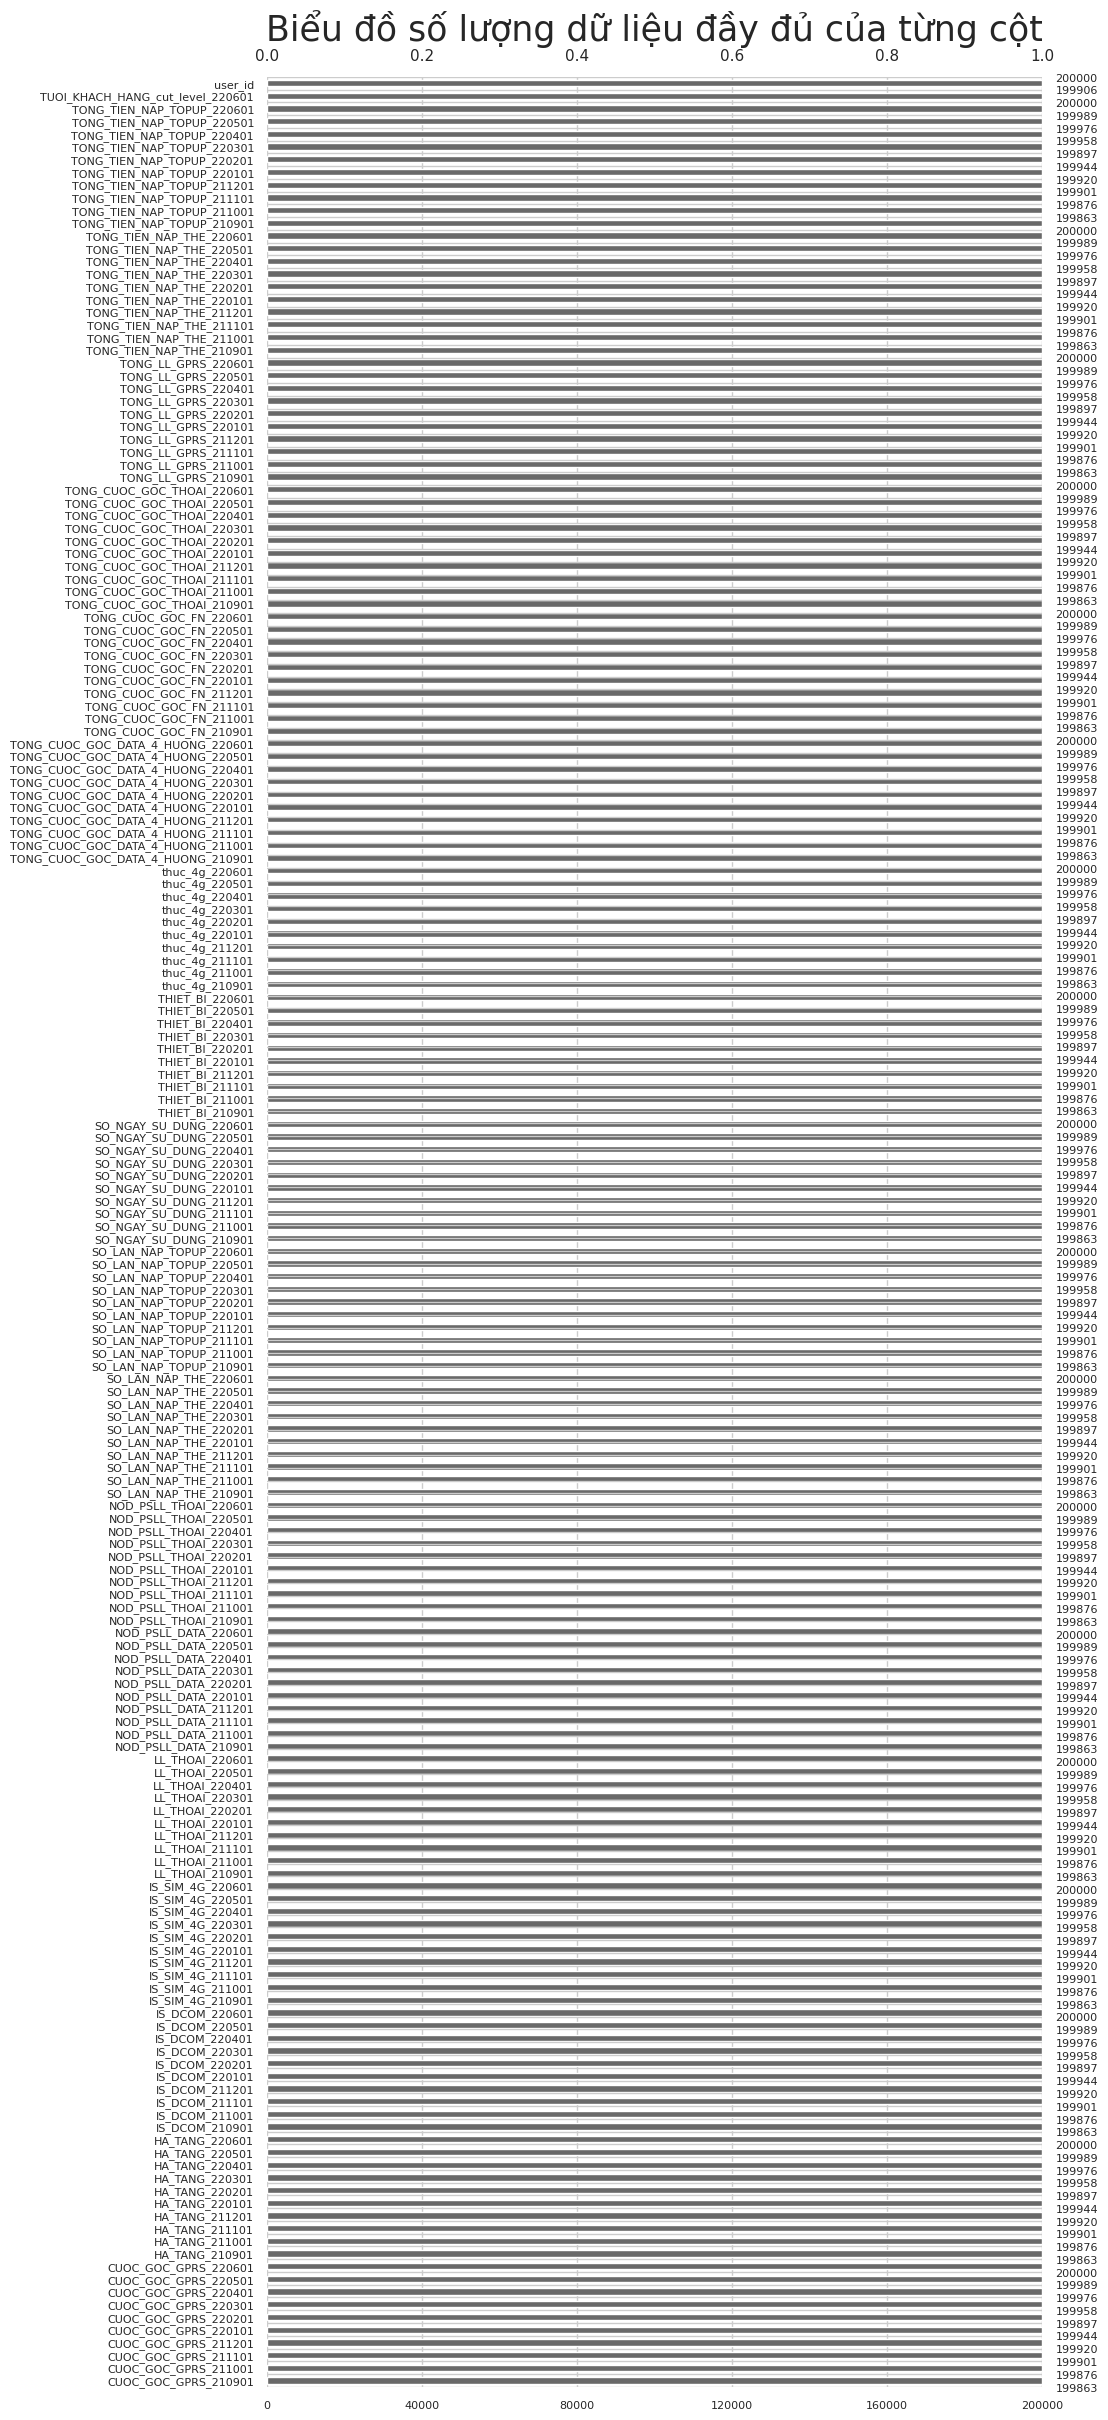

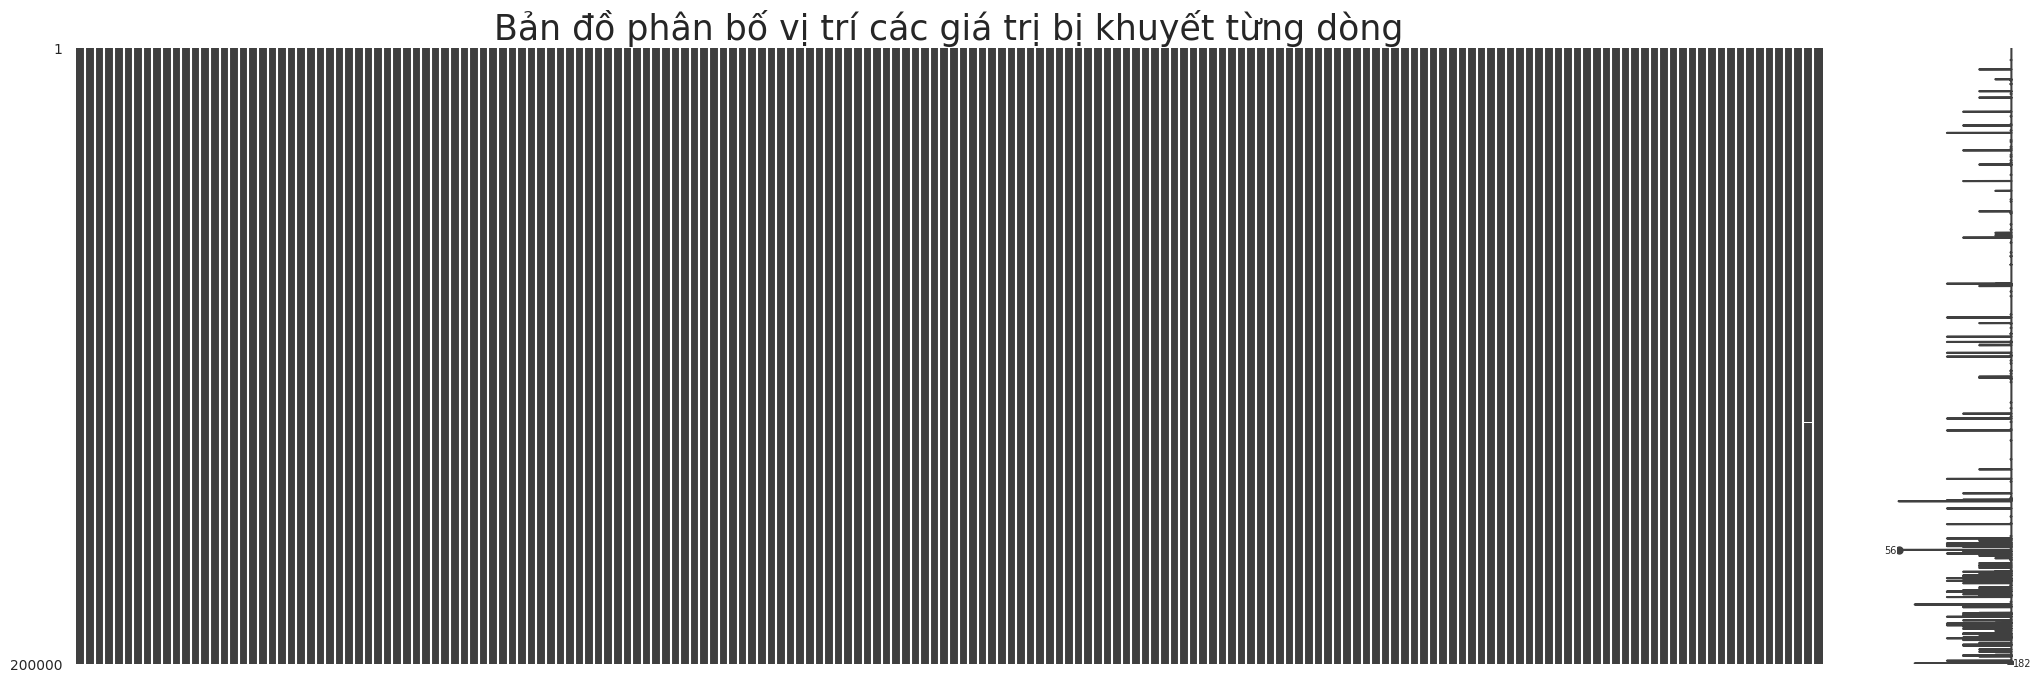

In [ ]:
#kiểm tra và xử lí missing value
msno.bar(df, figsize=(10, 30), fontsize = 8)
plt.title("Biểu đồ số lượng dữ liệu đầy đủ của từng cột", fontsize = 25)
plt.show()

msno.matrix(df, figsize=(25, 8), fontsize=8)
plt.title("Bản đồ phân bố vị trí các giá trị bị khuyết từng dòng", fontsize = 25)
plt.show()

Do số lượng ô bị khuyết thiếu chiếm rất nhỏ so với tổng thể, ta có thể tiến hành drop các user bị null để đảm bảo sự chính xác cho quá trình phân tích

In [ ]:
#lọc ra những khách hàng có giá trị missing
df = df[df.isnull().sum(axis = 1) == 0]
print(f"số lượng khách hàng còn lại sau khi lọc: {len(df)}")

số lượng khách hàng còn lại sau khi lọc: 199723


In [ ]:
#kiểm tra số lượng cột theo tháng
all_columns = pd.Series(df.columns)
base_columns = all_columns.str.replace(r'_\d+$','',regex = True)
column_count = base_columns.value_counts()
df_counts = column_count.reset_index()
df_counts.columns = ['Ten_Feature_Goc','So_Luong_Cot_theo_thang']
display(df_counts)

,Ten_Feature_Goc,So_Luong_Cot_theo_thang
0,CUOC_GOC_GPRS,10
1,HA_TANG,10
2,IS_DCOM,10
3,IS_SIM_4G,10
4,LL_THOAI,10
5,NOD_PSLL_DATA,10
6,NOD_PSLL_THOAI,10
7,SO_LAN_NAP_THE,10
8,SO_LAN_NAP_TOPUP,10
9,SO_NGAY_SU_DUNG,10


Có thể thấy mỗi một user đều có đủ data record cho 10 tháng

In [ ]:
#xử lí duplicated value
so_luong_trung = df.duplicated(subset = ['user_id']).sum()
print(f"số lượng khách hàng bị trùng lặp: {so_luong_trung}")

if so_luong_trung >0:
  tap_trung_lap = df[df.duplicated(subset=['user_id'], keep=False)]
  tap_trung_lap = tap_trung_lap.sort_values(by='user_id')

  print("\nChi tiết các dòng bị trùng lặp:")
  display(tap_trung_lap.head(20))


số lượng khách hàng bị trùng lặp: 16756

Chi tiết các dòng bị trùng lặp:


,CUOC_GOC_GPRS_210901,CUOC_GOC_GPRS_211001,CUOC_GOC_GPRS_211101,CUOC_GOC_GPRS_211201,CUOC_GOC_GPRS_220101,CUOC_GOC_GPRS_220201,CUOC_GOC_GPRS_220301,CUOC_GOC_GPRS_220401,CUOC_GOC_GPRS_220501,CUOC_GOC_GPRS_220601,HA_TANG_210901,HA_TANG_211001,HA_TANG_211101,HA_TANG_211201,HA_TANG_220101,HA_TANG_220201,HA_TANG_220301,HA_TANG_220401,HA_TANG_220501,HA_TANG_220601,IS_DCOM_210901,IS_DCOM_211001,IS_DCOM_211101,IS_DCOM_211201,IS_DCOM_220101,IS_DCOM_220201,IS_DCOM_220301,IS_DCOM_220401,IS_DCOM_220501,IS_DCOM_220601,IS_SIM_4G_210901,IS_SIM_4G_211001,IS_SIM_4G_211101,IS_SIM_4G_211201,IS_SIM_4G_220101,IS_SIM_4G_220201,IS_SIM_4G_220301,IS_SIM_4G_220401,IS_SIM_4G_220501,IS_SIM_4G_220601,LL_THOAI_210901,LL_THOAI_211001,LL_THOAI_211101,LL_THOAI_211201,LL_THOAI_220101,LL_THOAI_220201,LL_THOAI_220301,LL_THOAI_220401,LL_THOAI_220501,LL_THOAI_220601,NOD_PSLL_DATA_210901,NOD_PSLL_DATA_211001,NOD_PSLL_DATA_211101,NOD_PSLL_DATA_211201,NOD_PSLL_DATA_220101,NOD_PSLL_DATA_220201,NOD_PSLL_DATA_220301,NOD_PSLL_DATA_220401,NOD_PSLL_DATA_220501,NOD_PSLL_DATA_220601,NOD_PSLL_THOAI_210901,NOD_PSLL_THOAI_211001,NOD_PSLL_THOAI_211101,NOD_PSLL_THOAI_211201,NOD_PSLL_THOAI_220101,NOD_PSLL_THOAI_220201,NOD_PSLL_THOAI_220301,NOD_PSLL_THOAI_220401,NOD_PSLL_THOAI_220501,NOD_PSLL_THOAI_220601,SO_LAN_NAP_THE_210901,SO_LAN_NAP_THE_211001,SO_LAN_NAP_THE_211101,SO_LAN_NAP_THE_211201,SO_LAN_NAP_THE_220101,SO_LAN_NAP_THE_220201,SO_LAN_NAP_THE_220301,SO_LAN_NAP_THE_220401,SO_LAN_NAP_THE_220501,SO_LAN_NAP_THE_220601,SO_LAN_NAP_TOPUP_210901,SO_LAN_NAP_TOPUP_211001,SO_LAN_NAP_TOPUP_211101,SO_LAN_NAP_TOPUP_211201,SO_LAN_NAP_TOPUP_220101,SO_LAN_NAP_TOPUP_220201,SO_LAN_NAP_TOPUP_220301,SO_LAN_NAP_TOPUP_220401,SO_LAN_NAP_TOPUP_220501,SO_LAN_NAP_TOPUP_220601,SO_NGAY_SU_DUNG_210901,SO_NGAY_SU_DUNG_211001,SO_NGAY_SU_DUNG_211101,SO_NGAY_SU_DUNG_211201,SO_NGAY_SU_DUNG_220101,SO_NGAY_SU_DUNG_220201,SO_NGAY_SU_DUNG_220301,SO_NGAY_SU_DUNG_220401,SO_NGAY_SU_DUNG_220501,SO_NGAY_SU_DUNG_220601,THIET_BI_210901,THIET_BI_211001,THIET_BI_211101,THIET_BI_211201,THIET_BI_220101,THIET_BI_220201,THIET_BI_220301,THIET_BI_220401,THIET_BI_220501,THIET_BI_220601,thuc_4g_210901,thuc_4g_211001,thuc_4g_211101,thuc_4g_211201,thuc_4g_220101,thuc_4g_220201,thuc_4g_220301,thuc_4g_220401,thuc_4g_220501,thuc_4g_220601,TONG_CUOC_GOC_DATA_4_HUONG_210901,TONG_CUOC_GOC_DATA_4_HUONG_211001,TONG_CUOC_GOC_DATA_4_HUONG_211101,TONG_CUOC_GOC_DATA_4_HUONG_211201,TONG_CUOC_GOC_DATA_4_HUONG_220101,TONG_CUOC_GOC_DATA_4_HUONG_220201,TONG_CUOC_GOC_DATA_4_HUONG_220301,TONG_CUOC_GOC_DATA_4_HUONG_220401,TONG_CUOC_GOC_DATA_4_HUONG_220501,TONG_CUOC_GOC_DATA_4_HUONG_220601,TONG_CUOC_GOC_FN_210901,TONG_CUOC_GOC_FN_211001,TONG_CUOC_GOC_FN_211101,TONG_CUOC_GOC_FN_211201,TONG_CUOC_GOC_FN_220101,TONG_CUOC_GOC_FN_220201,TONG_CUOC_GOC_FN_220301,TONG_CUOC_GOC_FN_220401,TONG_CUOC_GOC_FN_220501,TONG_CUOC_GOC_FN_220601,TONG_CUOC_GOC_THOAI_210901,TONG_CUOC_GOC_THOAI_211001,TONG_CUOC_GOC_THOAI_211101,TONG_CUOC_GOC_THOAI_211201,TONG_CUOC_GOC_THOAI_220101,TONG_CUOC_GOC_THOAI_220201,TONG_CUOC_GOC_THOAI_220301,TONG_CUOC_GOC_THOAI_220401,TONG_CUOC_GOC_THOAI_220501,TONG_CUOC_GOC_THOAI_220601,TONG_LL_GPRS_210901,TONG_LL_GPRS_211001,TONG_LL_GPRS_211101,TONG_LL_GPRS_211201,TONG_LL_GPRS_220101,TONG_LL_GPRS_220201,TONG_LL_GPRS_220301,TONG_LL_GPRS_220401,TONG_LL_GPRS_220501,TONG_LL_GPRS_220601,TONG_TIEN_NAP_THE_210901,TONG_TIEN_NAP_THE_211001,TONG_TIEN_NAP_THE_211101,TONG_TIEN_NAP_THE_211201,TONG_TIEN_NAP_THE_220101,TONG_TIEN_NAP_THE_220201,TONG_TIEN_NAP_THE_220301,TONG_TIEN_NAP_THE_220401,TONG_TIEN_NAP_THE_220501,TONG_TIEN_NAP_THE_220601,TONG_TIEN_NAP_TOPUP_210901,TONG_TIEN_NAP_TOPUP_211001,TONG_TIEN_NAP_TOPUP_211101,TONG_TIEN_NAP_TOPUP_211201,TONG_TIEN_NAP_TOPUP_220101,TONG_TIEN_NAP_TOPUP_220201,TONG_TIEN_NAP_TOPUP_220301,TONG_TIEN_NAP_TOPUP_220401,TONG_TIEN_NAP_TOPUP_220501,TONG_TIEN_NAP_TOPUP_220601,TUOI_KHACH_HANG_cut_level_220601,user_id
148970,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4G,4G,4G,4G,4G,4G,4G,4G,4G,4G,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.0

Xuất hiện 16756 user id bị duplicate, có các trường hợp dẫn đến lỗi này:
- Trường hợp 1: SIM đổi chủ - có thể kiếm tra bằng việc kiểm tra cut-level tuổi của từng record theo user id
- Trường hợp 2: lỗi trong quá trình ETL/Data Pipeline -> nếu trong trường hợp này, sẽ aggreate theo phương pháp lấy sum ở các mức chi tiêu, lấy max ở các thiết bị sim 4g

In [ ]:
from inspect import AGEN_RUNNING
so_luong_trung = df.duplicated(subset=['user_id']).sum()
print(f"Phát hiện {so_luong_trung} dòng bị trùng lặp user_id!")
print(f"Tỷ lệ: {so_luong_trung/len(df)*100:.2f}% tổng số dòng")

if so_luong_trung > 0:
  tap_trung_lap = df[df.duplicated(subset=['user_id'], keep=False)]
  tap_trung_lap = tap_trung_lap.sort_values(by='user_id')

  print("\nChi tiết các dòng bị trùng lặp:")
  display(tap_trung_lap.head(20))

  # phân loại 2 giả thiết dựa trên tuoi_khach_hang_cut_level
  # Đã sửa: group_by -> groupby
  age_nunique = (tap_trung_lap
                .groupby('user_id')['TUOI_KHACH_HANG_cut_level_220601']
                .nunique())

  # giả thiết 1: tuổi giống nhau -> lỗi từ data pipeline/quy trình etl
  gt1_users = age_nunique[age_nunique==1].index
  # giả thiết 2: tuổi khác nhau -> sim đã đổi chủ
  gt2_users = age_nunique[age_nunique>1].index
  df_gt1 = tap_trung_lap[tap_trung_lap['user_id'].isin(gt1_users)]

  print(f"\n{'='*55}")
  print(f"GIẢ THIẾT 1 - Lỗi pipeline (tuổi giống nhau): "
        f"{len(gt1_users):,} users ({len(gt1_users)/len(age_nunique)*100:.1f}%) ")
  print(f"GIẢ THIẾT 2 - SIM đổi chủ  (tuổi khác nhau): "
        f"{len(gt2_users):,} users ({len(gt2_users)/len(age_nunique)*100:.1f}%) ")
  print(f"{'='*55}")

Phát hiện 16756 dòng bị trùng lặp user_id!
Tỷ lệ: 8.39% tổng số dòng

Chi tiết các dòng bị trùng lặp:


,CUOC_GOC_GPRS_210901,CUOC_GOC_GPRS_211001,CUOC_GOC_GPRS_211101,CUOC_GOC_GPRS_211201,CUOC_GOC_GPRS_220101,CUOC_GOC_GPRS_220201,CUOC_GOC_GPRS_220301,CUOC_GOC_GPRS_220401,CUOC_GOC_GPRS_220501,CUOC_GOC_GPRS_220601,HA_TANG_210901,HA_TANG_211001,HA_TANG_211101,HA_TANG_211201,HA_TANG_220101,HA_TANG_220201,HA_TANG_220301,HA_TANG_220401,HA_TANG_220501,HA_TANG_220601,IS_DCOM_210901,IS_DCOM_211001,IS_DCOM_211101,IS_DCOM_211201,IS_DCOM_220101,IS_DCOM_220201,IS_DCOM_220301,IS_DCOM_220401,IS_DCOM_220501,IS_DCOM_220601,IS_SIM_4G_210901,IS_SIM_4G_211001,IS_SIM_4G_211101,IS_SIM_4G_211201,IS_SIM_4G_220101,IS_SIM_4G_220201,IS_SIM_4G_220301,IS_SIM_4G_220401,IS_SIM_4G_220501,IS_SIM_4G_220601,LL_THOAI_210901,LL_THOAI_211001,LL_THOAI_211101,LL_THOAI_211201,LL_THOAI_220101,LL_THOAI_220201,LL_THOAI_220301,LL_THOAI_220401,LL_THOAI_220501,LL_THOAI_220601,NOD_PSLL_DATA_210901,NOD_PSLL_DATA_211001,NOD_PSLL_DATA_211101,NOD_PSLL_DATA_211201,NOD_PSLL_DATA_220101,NOD_PSLL_DATA_220201,NOD_PSLL_DATA_220301,NOD_PSLL_DATA_220401,NOD_PSLL_DATA_220501,NOD_PSLL_DATA_220601,NOD_PSLL_THOAI_210901,NOD_PSLL_THOAI_211001,NOD_PSLL_THOAI_211101,NOD_PSLL_THOAI_211201,NOD_PSLL_THOAI_220101,NOD_PSLL_THOAI_220201,NOD_PSLL_THOAI_220301,NOD_PSLL_THOAI_220401,NOD_PSLL_THOAI_220501,NOD_PSLL_THOAI_220601,SO_LAN_NAP_THE_210901,SO_LAN_NAP_THE_211001,SO_LAN_NAP_THE_211101,SO_LAN_NAP_THE_211201,SO_LAN_NAP_THE_220101,SO_LAN_NAP_THE_220201,SO_LAN_NAP_THE_220301,SO_LAN_NAP_THE_220401,SO_LAN_NAP_THE_220501,SO_LAN_NAP_THE_220601,SO_LAN_NAP_TOPUP_210901,SO_LAN_NAP_TOPUP_211001,SO_LAN_NAP_TOPUP_211101,SO_LAN_NAP_TOPUP_211201,SO_LAN_NAP_TOPUP_220101,SO_LAN_NAP_TOPUP_220201,SO_LAN_NAP_TOPUP_220301,SO_LAN_NAP_TOPUP_220401,SO_LAN_NAP_TOPUP_220501,SO_LAN_NAP_TOPUP_220601,SO_NGAY_SU_DUNG_210901,SO_NGAY_SU_DUNG_211001,SO_NGAY_SU_DUNG_211101,SO_NGAY_SU_DUNG_211201,SO_NGAY_SU_DUNG_220101,SO_NGAY_SU_DUNG_220201,SO_NGAY_SU_DUNG_220301,SO_NGAY_SU_DUNG_220401,SO_NGAY_SU_DUNG_220501,SO_NGAY_SU_DUNG_220601,THIET_BI_210901,THIET_BI_211001,THIET_BI_211101,THIET_BI_211201,THIET_BI_220101,THIET_BI_220201,THIET_BI_220301,THIET_BI_220401,THIET_BI_220501,THIET_BI_220601,thuc_4g_210901,thuc_4g_211001,thuc_4g_211101,thuc_4g_211201,thuc_4g_220101,thuc_4g_220201,thuc_4g_220301,thuc_4g_220401,thuc_4g_220501,thuc_4g_220601,TONG_CUOC_GOC_DATA_4_HUONG_210901,TONG_CUOC_GOC_DATA_4_HUONG_211001,TONG_CUOC_GOC_DATA_4_HUONG_211101,TONG_CUOC_GOC_DATA_4_HUONG_211201,TONG_CUOC_GOC_DATA_4_HUONG_220101,TONG_CUOC_GOC_DATA_4_HUONG_220201,TONG_CUOC_GOC_DATA_4_HUONG_220301,TONG_CUOC_GOC_DATA_4_HUONG_220401,TONG_CUOC_GOC_DATA_4_HUONG_220501,TONG_CUOC_GOC_DATA_4_HUONG_220601,TONG_CUOC_GOC_FN_210901,TONG_CUOC_GOC_FN_211001,TONG_CUOC_GOC_FN_211101,TONG_CUOC_GOC_FN_211201,TONG_CUOC_GOC_FN_220101,TONG_CUOC_GOC_FN_220201,TONG_CUOC_GOC_FN_220301,TONG_CUOC_GOC_FN_220401,TONG_CUOC_GOC_FN_220501,TONG_CUOC_GOC_FN_220601,TONG_CUOC_GOC_THOAI_210901,TONG_CUOC_GOC_THOAI_211001,TONG_CUOC_GOC_THOAI_211101,TONG_CUOC_GOC_THOAI_211201,TONG_CUOC_GOC_THOAI_220101,TONG_CUOC_GOC_THOAI_220201,TONG_CUOC_GOC_THOAI_220301,TONG_CUOC_GOC_THOAI_220401,TONG_CUOC_GOC_THOAI_220501,TONG_CUOC_GOC_THOAI_220601,TONG_LL_GPRS_210901,TONG_LL_GPRS_211001,TONG_LL_GPRS_211101,TONG_LL_GPRS_211201,TONG_LL_GPRS_220101,TONG_LL_GPRS_220201,TONG_LL_GPRS_220301,TONG_LL_GPRS_220401,TONG_LL_GPRS_220501,TONG_LL_GPRS_220601,TONG_TIEN_NAP_THE_210901,TONG_TIEN_NAP_THE_211001,TONG_TIEN_NAP_THE_211101,TONG_TIEN_NAP_THE_211201,TONG_TIEN_NAP_THE_220101,TONG_TIEN_NAP_THE_220201,TONG_TIEN_NAP_THE_220301,TONG_TIEN_NAP_THE_220401,TONG_TIEN_NAP_THE_220501,TONG_TIEN_NAP_THE_220601,TONG_TIEN_NAP_TOPUP_210901,TONG_TIEN_NAP_TOPUP_211001,TONG_TIEN_NAP_TOPUP_211101,TONG_TIEN_NAP_TOPUP_211201,TONG_TIEN_NAP_TOPUP_220101,TONG_TIEN_NAP_TOPUP_220201,TONG_TIEN_NAP_TOPUP_220301,TONG_TIEN_NAP_TOPUP_220401,TONG_TIEN_NAP_TOPUP_220501,TONG_TIEN_NAP_TOPUP_220601,TUOI_KHACH_HANG_cut_level_220601,user_id
148970,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4G,4G,4G,4G,4G,4G,4G,4G,4G,4G,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.0


GIẢ THIẾT 1 - Lỗi pipeline (tuổi giống nhau): 2,967 users (18.9%) 
GIẢ THIẾT 2 - SIM đổi chủ  (tuổi khác nhau): 12,707 users (81.1%) 


- Nhóm 1 (Lỗi Pipeline - 18.9%): Vì đây là cùng một người dùng nhưng bị nhân bản dòng, ta cần Gộp (Aggregate) dữ liệu. Các cột chi tiêu (cước phí, lưu lượng) sẽ lấy tổng (sum), các cột trạng thái (4G, thiết bị) sẽ lấy giá trị cao nhất (max)
- Nhóm 2 (SIM đổi chủ - 81.1%): Vì ID cũ thuộc về người đã rời mạng, ta cần Loại bỏ bản ghi cũ và chỉ giữ lại bản ghi mới nhất để mô hình không bị nhiễu bởi hành vi của chủ cũ.

In [ ]:
#xác định cột
df.columns = df.columns.str.lower()

ha_tang_cols = [c for c in df.columns if 'ha_tang' in c]
thiet_bi_cols = [c for c in df.columns if 'thiet_bi' in c]

#clean dữ liệu
def clean_telco(x):
  if pd.isna(x):
    return 'UNKNOWN'
  x = str(x)
  x = x.strip()
  x = re.sub(r'\s+', '',x)
  return x.upper()

for col in ha_tang_cols + thiet_bi_cols:
  df[col] = df[col].apply(clean_telco)

#mapping
infra_rank = {
     'UNKNOWN': 0,
    '-1G': -1,
    'G': 1,
    '2G': 2,
    '3G': 3,
    '4G': 4,
    '5G': 5
}

device_rank = infra_rank.copy()
#debug before mapping
print("\n=== CHECK VALUE TRƯỚC KHI MAP ===")
for col in ha_tang_cols[:1]:
  print(f"{col} unique:", set(df[col].unique()) - set(infra_rank.keys()))
#map
for col in ha_tang_cols:
  df[col] = df[col].map(infra_rank)
for col in thiet_bi_cols:
  df[col] = df[col].map(device_rank)
#check mapping fail
print("\n=== CHECK VALUE SAU KHI MAP ===")
for col in ha_tang_cols[:1]:
  print(df[col].value_counts(dropna=False))
# Fill NA sau khi đã debug
for col in ha_tang_cols + thiet_bi_cols:
    df[col] = df[col].fillna(-2).astype(int)


=== CHECK VALUE TRƯỚC KHI MAP ===
ha_tang_210901 unique: set()

=== CHECK VALUE SAU KHI MAP ===
ha_tang_210901
 4    116584
 2     50133
 3     18267
-1     14739
Name: count, dtype: int64


In [ ]:
# 1. Tách dataframe thành các phần khác nhau để xử lý
df_no_duplicates = df[~df['user_id'].isin(age_nunique.index)]
df_gt1_to_process = df[df['user_id'].isin(gt1_users)]
df_gt2_to_process = df[df['user_id'].isin(gt2_users)]

# 2. Xử lý GT1: Aggregate (Gộp dữ liệu)
# Xác định các cột số (cần sum) và các cột phân loại/flag (cần max/first)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'user_id' in num_cols: num_cols.remove('user_id')

agg_dict = {col: 'sum' if any(kw in col for kw in ['CUOC', 'TIEN', 'LL', 'NOD', 'SO_LAN']) else 'max' for col in df.columns if col != 'user_id'}

df_gt1_fixed = df_gt1_to_process.groupby('user_id').agg(agg_dict).reset_index()

# 3. Xử lý GT2: Keep Last (Giữ bản ghi mới nhất)
# Giả định thứ tự dữ liệu cuối cùng là mới nhất, hoặc có thể sort theo cột thời gian nếu có
df_gt2_fixed = df_gt2_to_process.drop_duplicates(subset=['user_id'], keep='last')

# 4. Gộp lại thành dataframe sạch
df_clean = pd.concat([df_no_duplicates, df_gt1_fixed, df_gt2_fixed], ignore_index=True)

print(f"Kích thước ban đầu: {len(df)}")
print(f"Kích thước sau khi làm sạch: {len(df_clean)}")
print(f"Số lượng user duy nhất: {df_clean['user_id'].nunique()}")



Kích thước ban đầu: 199723
Kích thước sau khi làm sạch: 182967
Số lượng user duy nhất: 182967


In [ ]:
print("\nDuplicate user_id:", df.duplicated('user_id').sum())

print("\nPhân bổ hạ tầng tháng cuối:")
print(df[ha_tang_cols[-1]].value_counts().sort_index())

print("\nPhân bổ thiết bị tháng cuối:")
print(df[thiet_bi_cols[-1]].value_counts().sort_index())


Duplicate user_id: 16756

Phân bổ hạ tầng tháng cuối:
ha_tang_220601
1     18665
2     43002
3     12357
4    125699
Name: count, dtype: int64

Phân bổ thiết bị tháng cuối:
thiet_bi_220601
0     15704
2     46873
3      2111
4    129199
5      5836
Name: count, dtype: int64


In [ ]:
import re

#chuẩn hóa tên cột về lower case để xử lí nhất quán
df.columns = df.columns.str.lower()
print("ví dụ tên cột sau lowercase: ")
print(list(df.columns[:10]))
#tách feature và tháng từ tên cột-pattern: tên_cột_YYMMDD
pattern = re.compile(r'^(.*)_(\d{6})$')

records = []
for col in df.columns:
  if col == 'user_id':
    continue
  m = pattern.match(col)
  if m:
    records.append({
        'col': col,
        'feature': m.group(1),
        'month': m.group(2),
    })
col_map = pd.DataFrame(records)
print(f"\nTổng cột có suffix tháng : {len(col_map)}")
print(f"Số feature gốc duy nhất  : {col_map['feature'].nunique()}")
print(f"Số tháng duy nhất        : {col_map['month'].nunique()}")
print(f"\nDanh sách feature gốc:")
for f in sorted(col_map['feature'].unique()):
    n_months = col_map[col_map['feature'] == f]['month'].nunique()
    status   = "✓" if n_months == col_map['month'].nunique() else f"⚠ chỉ có {n_months} tháng"
    print(f"  {status}  {f}")



ví dụ tên cột sau lowercase: 
['cuoc_goc_gprs_210901', 'cuoc_goc_gprs_211001', 'cuoc_goc_gprs_211101', 'cuoc_goc_gprs_211201', 'cuoc_goc_gprs_220101', 'cuoc_goc_gprs_220201', 'cuoc_goc_gprs_220301', 'cuoc_goc_gprs_220401', 'cuoc_goc_gprs_220501', 'cuoc_goc_gprs_220601']

Tổng cột có suffix tháng : 181
Số feature gốc duy nhất  : 19
Số tháng duy nhất        : 10

Danh sách feature gốc:
  ✓  cuoc_goc_gprs
  ✓  ha_tang
  ✓  is_dcom
  ✓  is_sim_4g
  ✓  ll_thoai
  ✓  nod_psll_data
  ✓  nod_psll_thoai
  ✓  so_lan_nap_the
  ✓  so_lan_nap_topup
  ✓  so_ngay_su_dung
  ✓  thiet_bi
  ✓  thuc_4g
  ✓  tong_cuoc_goc_data_4_huong
  ✓  tong_cuoc_goc_fn
  ✓  tong_cuoc_goc_thoai
  ✓  tong_ll_gprs
  ✓  tong_tien_nap_the
  ✓  tong_tien_nap_topup
  ⚠ chỉ có 1 tháng  tuoi_khach_hang_cut_level


In [ ]:
months_sorted = sorted(col_map['month'].unique())
features_all  = sorted(col_map['feature'].unique())

df_long_list = []

for month in months_sorted:
    cols_this_month = col_map[col_map['month'] == month].set_index('feature')['col'].to_dict()

    subset = df[['user_id'] + list(cols_this_month.values())].copy()
    subset = subset.rename(columns={v: k for k, v in cols_this_month.items()})
    subset['date'] = pd.to_datetime(month, format='%y%m%d').strftime('%Y-%m')

    for feat in features_all:
        if feat not in subset.columns:
            subset[feat] = np.nan

    df_long_list.append(subset)

df_long = (pd.concat(df_long_list, ignore_index=True)
             .sort_values(['user_id', 'date'])
             .reset_index(drop=True))

col_order = ['user_id', 'date'] + features_all
df_long   = df_long[col_order]

#fix nan cho cột chỉ có 1 tháng
tuoi_cols = [c for c in df_long.columns if 'tuoi' in c.lower()]

if tuoi_cols:
    for col in tuoi_cols:
        df_long[col] = (df_long
                        .groupby('user_id')[col]
                        .transform(lambda x: x.ffill().bfill()))
    print(f"Đã fill {len(tuoi_cols)} cột tuổi: {tuoi_cols}")
#kiểm tra
print(f"Wide : {df.shape}")
print(f"Long : {df_long.shape}")
print(f"Kỳ vọng rows : {df['user_id'].nunique():,} × "
      f"{len(months_sorted)} tháng = "
      f"{df['user_id'].nunique() * len(months_sorted):,}")

nan_check = df_long.isnull().sum()
nan_check = nan_check[nan_check > 0]
if len(nan_check):
    print(f"\n⚠️  Cột có NaN còn lại:")
    print(nan_check)
else:
    print("\n✓ Không có NaN")

print(f"\nCác cột trong long table ({len(df_long.columns)}):")
print(df_long.dtypes)

print(f"\nVí dụ 1 user qua các tháng:")
sample_user = df_long['user_id'].iloc[0]
display(df_long[df_long['user_id'] == sample_user])


Đã fill 1 cột tuổi: ['tuoi_khach_hang_cut_level']
Wide : (199723, 182)
Long : (1997230, 21)
Kỳ vọng rows : 182,967 × 10 tháng = 1,829,670

✓ Không có NaN

Các cột trong long table (21):
user_id                        object
date                           object
cuoc_goc_gprs                 float64
ha_tang                         int64
is_dcom                       float64
is_sim_4g                     float64
ll_thoai                      float64
nod_psll_data                 float64
nod_psll_thoai                float64
so_lan_nap_the                float64
so_lan_nap_topup              float64
so_ngay_su_dung               float64
thiet_bi                        int64
thuc_4g                       float64
tong_cuoc_goc_data_4_huong    float64
tong_cuoc_goc_fn              float64
tong_cuoc_goc_thoai           float64
tong_ll_gprs                  float64
tong_tien_nap_the             float64
tong_tien_nap_topup           float64
tuoi_khach_hang_cut_level      object
dtype: object

V

,user_id,date,cuoc_goc_gprs,ha_tang,is_dcom,is_sim_4g,ll_thoai,nod_psll_data,nod_psll_thoai,so_lan_nap_the,so_lan_nap_topup,so_ngay_su_dung,thiet_bi,thuc_4g,tong_cuoc_goc_data_4_huong,tong_cuoc_goc_fn,tong_cuoc_goc_thoai,tong_ll_gprs,tong_tien_nap_the,tong_tien_nap_topup,tuoi_khach_hang_cut_level
0,100004000000,2021-09,0.0,4,0.0,1.0,920.0,0.0,11.0,1.0,0.0,30.0,4,1.0,0.0,13885.19,13885.19,0.000000e+00,20000.0,0.0,35 < X <= 45
1,100004000000,2021-10,0.0,4,0.0,1.0,436.0,1.0,3.0,1.0,1.0,31.0,4,1.0,15000.0,23496.88,8246.88,5.412390e+06,20000.0,20000.0,35 < X <= 45
2,100004000000,2021-11,0.0,4,0.0,1.0,1338.0,24.0,15.0,1.0,1.0,30.0,2,1.0,5000.0,32396.68,19996.68,2.024682e+08,50000.0,50000.0,35 < X <= 45
3,100004000000,2021-12,0.0,2,0.0,1.0,2236.0,31.0,7.0,1.0,1.0,31.0,2,0.0,15000.0,34097.30,13197.30,5.780800e+04,10000.0,10000.0,35 < X <= 45
4,100004000000,2022-01,0.0,2,0.0,1.0,29.0,14.0,2.0,1.0,1.0,15.0,2,0.0,0.0,768.50,768.50,7.949000e+03,10000.0,10000.0,35 < X <= 45
5,100004000000,2022-02,0.0,2,0.0,1.0,205.0,6.0,6.0,1.0,0.0,13.0,2,0.0,15000.0,20612.34,5612.34,2.212000e+03,20000.0,0.0,35 < X <= 45
6,100004000000,2022-03,0.0,4,0.0,1.0,576.0,19.0,6.0,3.0,3.0,25.0,4,1.0,50000.0,62390.00,12190.00,2.709494e+09,60000.0,60000.0,35 < X <= 45
7,100004000000,2022-04,0.0,4,0.0,1.0,492.0,12.0,4.0,1.0,1.0,30.0,4,1.0,30000.0,46610.86,13610.86,5.853116e+09,50000.0,50000.0,35 < X <= 45
8,100004000000,2022-05,0.0,4,0.0,1.0,226.0,0.0,7.0,2.0,2.0,31.0,4,1.0,0.0,5989.00,5989.00,0.000000e+00,20000.0,20000.0,35 < X <= 45
9,100004000000,2022-06,0.0,4,0.0,1.0,143.0,0.0,7.0,2.0,2.0,30.0,4,1.0,0.0,8789.50,3789.50,0.000000e+00,20000.0,20000.0,35 < X <= 45


xác định mục tiêu bài toán: tìm hiểu các yếu tố động lực để thúc đấy người dùng chuyển đổi lên 4g

In [ ]:
#đảm bảo date đúng format
df_long['date'] = pd.to_datetime(df_long['date'])
# Sort theo user + thời gian
df_long = df_long.sort_values(['user_id', 'date'])
#tạo biến target
df_long['thuc_4g_next'] = (df_long.groupby('user_id')['thuc_4g'].shift(-1))

df_model = df_long.dropna(subset=['thuc_4g_next']).copy()
df_model = df_model[df_model['thuc_4g'] == 0].copy()
df_model['thuc_4g_next'] = df_model['thuc_4g_next'].astype(int)
print("Shape:", df_model.shape)

print("\nPhân bổ label:")
print(df_model['thuc_4g_next'].value_counts(normalize=True))

print("\nVí dụ 1 user:")
sample_user = df_model['user_id'].iloc[0]
display(df_model[df_model['user_id'] == sample_user])

Shape: (938349, 22)

Phân bổ label:
thuc_4g_next
0    0.835356
1    0.164644
Name: proportion, dtype: float64

Ví dụ 1 user:


,user_id,date,cuoc_goc_gprs,ha_tang,is_dcom,is_sim_4g,ll_thoai,nod_psll_data,nod_psll_thoai,so_lan_nap_the,so_lan_nap_topup,so_ngay_su_dung,thiet_bi,thuc_4g,tong_cuoc_goc_data_4_huong,tong_cuoc_goc_fn,tong_cuoc_goc_thoai,tong_ll_gprs,tong_tien_nap_the,tong_tien_nap_topup,tuoi_khach_hang_cut_level,thuc_4g_next
3,100004000000,2021-12-01,0.0,2,0.0,1.0,2236.0,31.0,7.0,1.0,1.0,31.0,2,0.0,15000.0,34097.30,13197.30,57808.0,10000.0,10000.0,35 < X <= 45,0
4,100004000000,2022-01-01,0.0,2,0.0,1.0,29.0,14.0,2.0,1.0,1.0,15.0,2,0.0,0.0,768.50,768.50,7949.0,10000.0,10000.0,35 < X <= 45,0
5,100004000000,2022-02-01,0.0,2,0.0,1.0,205.0,6.0,6.0,1.0,0.0,13.0,2,0.0,15000.0,20612.34,5612.34,2212.0,20000.0,0.0,35 < X <= 45,1


kết thúc giai đoạn data processing, tiến hành quá trình EDA để tìm ra chân dung khách hàng

# EDA
Để xác định được khả năng của một khách hàng chuyển đổi từ 2g lên 4g, có thể chia thành các yếu tố cơ bản sau mà bộ dữ liệu có thể đáp ứng:

Khả năng rào cản:
- thiết bị và hạ tầng của người dùng có đảm bảo cho khả năng chuyển đổi sang 4g không ? Nếu đã đủ yêu cầu thì tại sao khách hàng không có nhu cầu lên

Nhu cầu sử dụng và hành vi:
- Người dùng có sử dụng data nhiều hơn trước khi convert hay không ?
- Tần suất nạp tiền chi tiêu và thời gian sử dụng có nhiều hơn trước khi convert hay không
- Người chỉ gọi/thoại nhiều hay người dùng data nhiều sẽ có khả năng convert cao hơn ?
- Nhóm khách hàng high-value có khả năng chuyển đổi cao hơn hay không ?




In [ ]:
df_model.head()

,user_id,date,cuoc_goc_gprs,ha_tang,is_dcom,is_sim_4g,ll_thoai,nod_psll_data,nod_psll_thoai,so_lan_nap_the,so_lan_nap_topup,so_ngay_su_dung,thiet_bi,thuc_4g,tong_cuoc_goc_data_4_huong,tong_cuoc_goc_fn,tong_cuoc_goc_thoai,tong_ll_gprs,tong_tien_nap_the,tong_tien_nap_topup,tuoi_khach_hang_cut_level,thuc_4g_next
3,100004000000,2021-12-01,0.0,2,0.0,1.0,2236.0,31.0,7.0,1.0,1.0,31.0,2,0.0,15000.0,34097.30,13197.30,57808.0,10000.0,10000.0,35 < X <= 45,0
4,100004000000,2022-01-01,0.0,2,0.0,1.0,29.0,14.0,2.0,1.0,1.0,15.0,2,0.0,0.0,768.50,768.50,7949.0,10000.0,10000.0,35 < X <= 45,0
5,100004000000,2022-02-01,0.0,2,0.0,1.0,205.0,6.0,6.0,1.0,0.0,13.0,2,0.0,15000.0,20612.34,5612.34,2212.0,20000.0,0.0,35 < X <= 45,1
17,100008000000,2022-04-01,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,4,0.0,0.0,0.00,0.00,0.0,0.0,0.0,65 < X <= 75,0
18,100008000000,2022-05-01,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,7.0,4,0.0,0.0,7000.00,0.00,0.0,0.0,0.0,65 < X <= 75,0


In [ ]:
df_model.describe()

,date,cuoc_goc_gprs,ha_tang,is_dcom,is_sim_4g,ll_thoai,nod_psll_data,nod_psll_thoai,so_lan_nap_the,so_lan_nap_topup,so_ngay_su_dung,thiet_bi,thuc_4g,tong_cuoc_goc_data_4_huong,tong_cuoc_goc_fn,tong_cuoc_goc_thoai,tong_ll_gprs,tong_tien_nap_the,tong_tien_nap_topup,thuc_4g_next
count,938349,9.383490e+05,938349.000000,938349.000000,938349.000000,938349.000000,938349.000000,938349.000000,938349.000000,938349.000000,938349.000000,938349.000000,938349.0,9.383490e+05,9.383490e+05,9.383490e+05,9.383490e+05,9.383490e+05,9.383490e+05,938349.000000
mean,2021-12-30 17:46:29.104267008,1.754223e+01,2.380609,0.024502,0.868506,1796.539141,4.194004,8.266552,0.692035,0.183215,16.662745,2.629796,0.0,3.973098e+03,2.940274e+04,1.775150e+04,5.864057e+08,2.977579e+04,9.690357e+03,0.164644
min,2021-09-01 00:00:00,0.000000e+00,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2021-11-01 00:00:00,0.000000e+00,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,2022-01-01 00:00:00,0.000000e+00,2.000000,0.000000,1.000000,164.000000,0.000000,4.000000,0.000000,0.000000,17.000000,2.000000,0.0,0.000000e+00,5.000000e+03,1.391500e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
75%,2022-03-01 00:00:00,0.000000e+00,3.000000,0.000000,1.000000,1443.000000,2.000000,15.000000,1.000000,0.000000,29.000000,4.000000,0.0,0.000000e+00,3.595674e+04,1.940050e+04,1.440900e+04,4.000000e+04,0.000000e+00,0.000000
max,2022-06-01 00:00:00,2.131197e+06,4.000000,5.000000,1.000000,677373.000000,31.000000,31.000000,256.000000,107.000000,31.000000,5.000000,0.0,5.657974e+06,2.894900e+07,3.251764e+06,4.898080e+11,2.880000e+07,8.500000e+06,1.000000
std,NaN,2.514197e+03,1.268313,0.258271,0.337940,6558.073836,9.128147,9.673012,1.539234,0.640663,11.518399,1.312435,0.0,2.002013e+04,7.685641e+04,4.154326e+04,5.261097e+09,8.569873e+04,4.057825e+04,0.370860


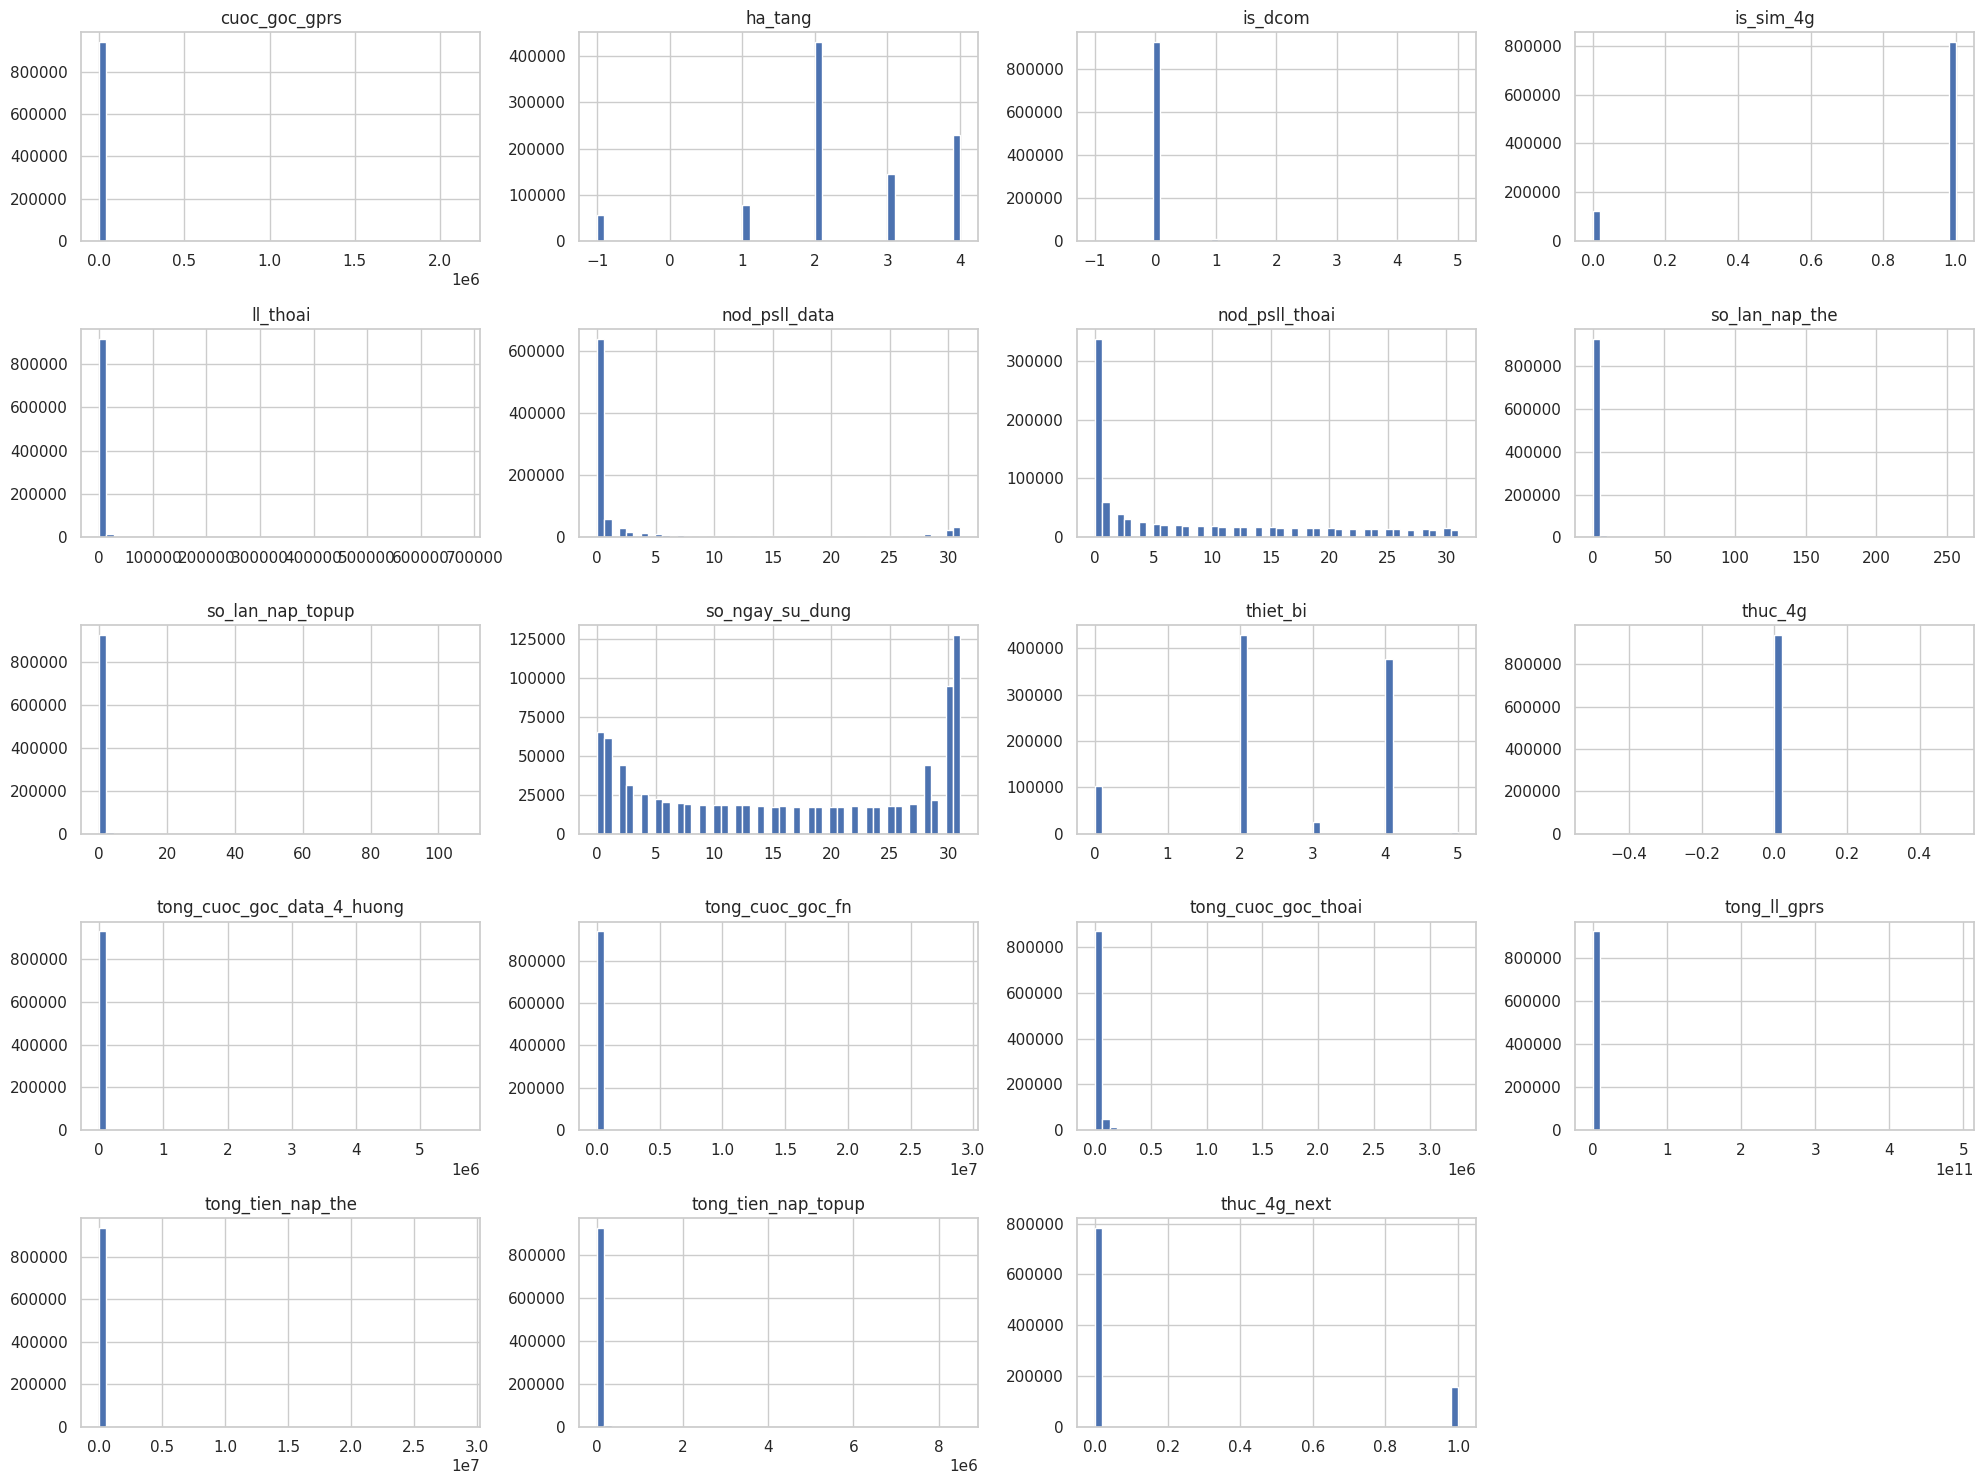

In [ ]:
num_cols = df_model.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20,15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 4, i)
    plt.hist(df_model[col], bins=50)
    plt.title(col)

plt.tight_layout()
plt.show()

Nhận xét:
- các biến về chi tiêu, lưu lượng data và thoại đều lệch phải mạnh -> có thể thấy phần lớn người dùng có mức sử dụng thấp, trong khi đó tồn tại một nhóm nhỏ người dùng có mức sử dụng khá cao
- Biến is_sim_4g tập trung chủ yếu bằng 1, trong khi thuc_4g hầu hết lại bằng 0, một số nguyên nhân tiềm năng có thể bao gồm hạn chế về thiết bị, thói quen sử dụng hoặc nhu cầu về sử dụng data chưa cao. Về điều này, cần được kiểm chứng thêm từ các biến liên quan như thiết bị, hành vi sử dụng data
- Số lượng khách hàng có số ngày sử dụng lớn hơn 30 ngày lớn -> cho thấy phần lớn khách hàng active thường xuyên, dấu hiệu tốt để khai thác chuyển đổi
- Biến target thuc_4g_next đang mất cân bằng khá nghiêm trọng

Kiếm tra yếu tố về rào cản hạ tầng thiết bị:
- thiết bị và hạ tầng của họ có đảm bảo cho khả năng chuyển đổi lên 4g không ? nếu đã đảm bảo được, vì sao họ k có nhu cầu lên

tạo ra df_user mới bao gồm user và thiết bị, cũng nhu sim đã được nâng cấp lên mức tối đa

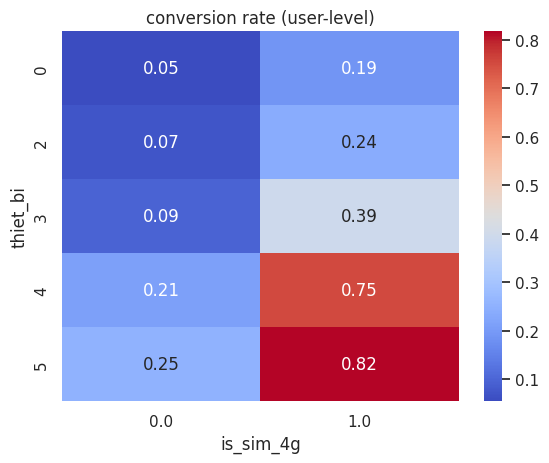

In [ ]:
df_user = (
    df_model
    .sort_values('date')
    .groupby('user_id')
    .agg({
        'thiet_bi': 'max',
        'is_sim_4g': 'max',
        'thuc_4g_next':'max'
    })
    .reset_index()
)
pivot = pd.pivot_table(
    df_user,
    index='thiet_bi',
    columns='is_sim_4g',
    values='thuc_4g_next', # Explicitly specify the column to aggregate
    aggfunc='mean')

sns.heatmap(pivot, annot =True, fmt=".2f", cmap="coolwarm")
plt.title("conversion rate (user-level)")
plt.show()

- Thiết bị và sim 4g là điều kiện cần dể khách hàng sẵn sàng chuyển đổi, nhìn vào biểu đồ ta thấy các khách hàng đủ điều kiện tỉ lệ chuyển đối lên 82% và 75% tuy nhiên vẫn còn 18% nhóm khách hàng còn lại vẫn chưa chuyển đổi, cần phải phân tích kỹ hơn vào nhóm 18% đã đủ điều kiện này

- Đối với nhóm khách hàng chưa đủ điều kiện thiếu SIM 4G hoặc thiết bị, tỷ lệ chuyển đổi khá thấp, khẳng định rằng các yếu tố kỹ thuật là rào cản mang tính quyết định trong giai đoạn đầu của hành trình chuyển đổi.

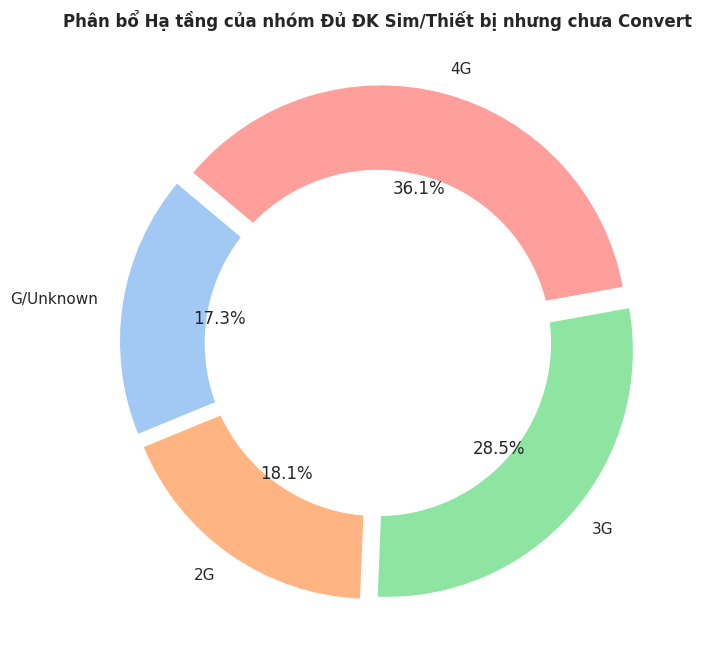

In [ ]:
# 1. Trích xuất hạ tầng mới nhất
df_ha_tang = df_model.sort_values('date').groupby('user_id')['ha_tang'].last().reset_index()
df_user_new = pd.merge(df_user, df_ha_tang, on='user_id', how='left')

# 2. Lọc nhóm '18%': Đã đủ Sim 4G (1.0) và Thiết bị 4G/5G (>=4) nhưng CHƯA chuyển đổi (thuc_4g_next == 0)
df_target_group = df_user_new[
    (df_user_new['is_sim_4g'] == 1) &
    (df_user_new['thiet_bi'] >= 4) &
    (df_user_new['thuc_4g_next'] == 0)
]

# 3. Vẽ biểu đồ cho riêng nhóm này để kiểm tra rào cản sóng
infra_counts = df_target_group['ha_tang'].value_counts().sort_index()
# Map nhãn để dễ đọc
infra_labels = {1: 'G/Unknown', 2: '2G', 3: '3G', 4: '4G'}
labels = [infra_labels.get(i, str(i)) for i in infra_counts.index]

plt.figure(figsize=(8,8))
plt.pie(infra_counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('pastel'), explode=[0.05]*len(infra_counts))
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.title("Phân bổ Hạ tầng của nhóm Đủ ĐK Sim/Thiết bị nhưng chưa Convert", fontsize=12, fontweight='bold')
plt.show()

Tỷ lệ hạ tầng nhóm người dùng đạt đủ điều kiện về sim và thiết bị 4g nhưng chưa convert lên 4g cho thấy chỉ có khoảng 36% nhóm người dùng đủ điều kiện nhưng chưa lên, còn lại 2g hoặc 3g chiếm khoảng 46%, rào cản về hạ tầng có thể là ảnh hưởng lớn

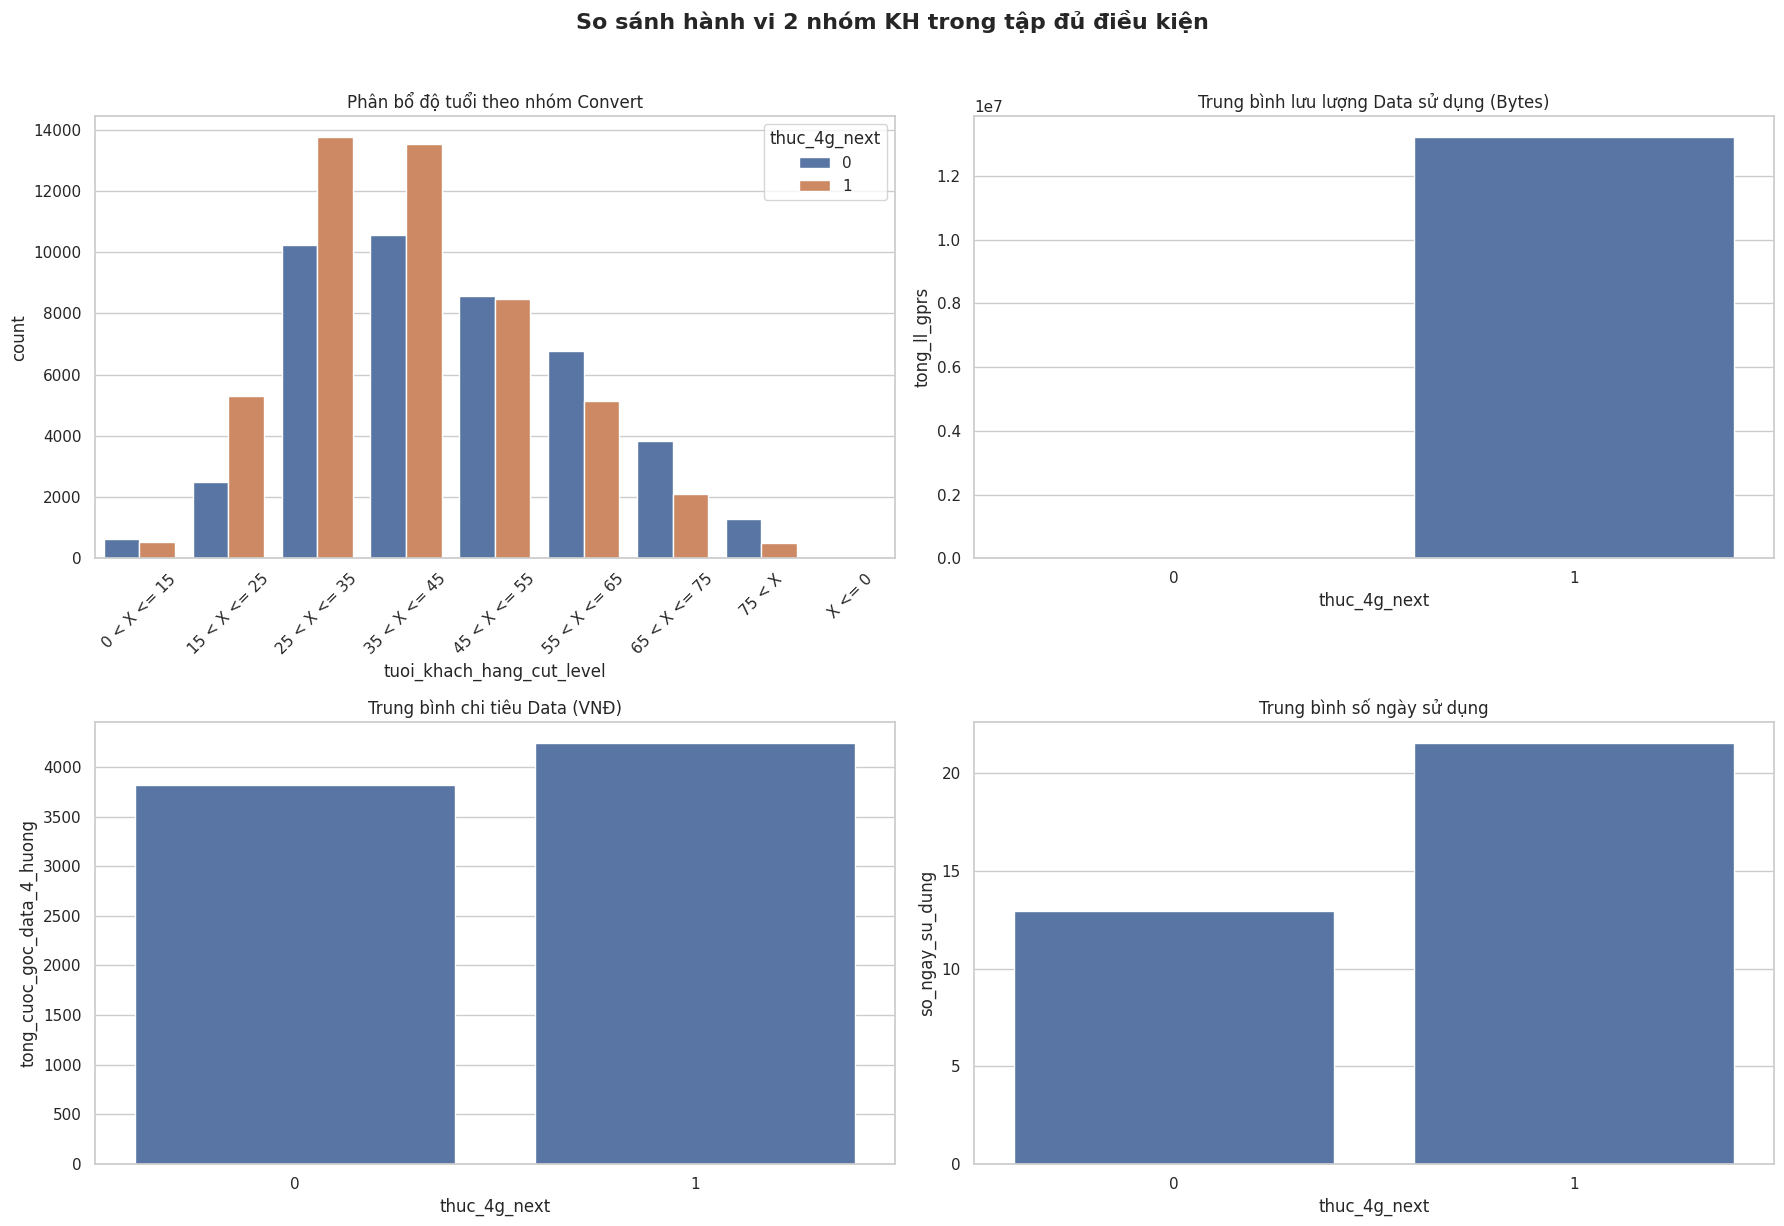

In [ ]:
df_user = (
    df_model
    .sort_values('date')
    .groupby('user_id')
    .agg({
        'thiet_bi': 'last',
        'is_sim_4g': 'max',
        'thuc_4g_next': 'max',
        'tong_ll_gprs': 'mean',
        'tong_cuoc_goc_data_4_huong': 'mean',
        'so_ngay_su_dung': 'mean',
        'tuoi_khach_hang_cut_level': 'last',
    })
    .reset_index()
)

# REMOVE OUTLIER để tính trung bình
def remove_outlier_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

df_clean = df_user.copy()

cols = ['tong_ll_gprs', 'tong_cuoc_goc_data_4_huong', 'so_ngay_su_dung']
for col in cols:
    df_clean = (
        df_clean
        .groupby('thuc_4g_next', group_keys=False)
        .apply(lambda x: remove_outlier_iqr(x, col))
        .reset_index(drop=True)
    )

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Age Distribution (Sửa lỗi: Bổ sung biểu đồ vẽ vào axes[0, 0])
sns.countplot(
    data=df_clean,
    x='tuoi_khach_hang_cut_level',
    hue='thuc_4g_next',
    ax=axes[0, 0],
    order=sorted(df_clean['tuoi_khach_hang_cut_level'].unique())
)
axes[0, 0].set_title("Phân bổ độ tuổi theo nhóm Convert")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Mean Data Usage
usage = df_clean.groupby('thuc_4g_next')['tong_ll_gprs'].mean().reset_index()
sns.barplot(data=usage, x='thuc_4g_next', y='tong_ll_gprs', ax=axes[0, 1])
axes[0, 1].set_title("Trung bình lưu lượng Data sử dụng (Bytes)")

# 3. Mean Data Spending
data_spending = df_user.groupby('thuc_4g_next')['tong_cuoc_goc_data_4_huong'].mean().reset_index()
sns.barplot(data=data_spending, x='thuc_4g_next', y='tong_cuoc_goc_data_4_huong', ax=axes[1, 0])
axes[1, 0].set_title("Trung bình chi tiêu Data (VNĐ)")

# 4. Mean Active Days
active_days = df_clean.groupby('thuc_4g_next')['so_ngay_su_dung'].mean().reset_index()
sns.barplot(data=active_days, x='thuc_4g_next', y='so_ngay_su_dung', ax=axes[1, 1])
axes[1, 1].set_title("Trung bình số ngày sử dụng")

plt.suptitle("So sánh hành vi 2 nhóm KH trong tập đủ điều kiện", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Xem xét kỹ nhóm người dùng k có nhu cầu convert chiếm 39.6% trong nhóm user đạt đủ điều kiện cho thấy:

Nhóm convert sử dụng data cao hơn đáng kể và active trung bình 23 ngày/tháng so với 13 ngày/tháng của nhóm không convert, cho thấy đây là nhóm KH có nhu cầu thực sự với dịch vụ di động.

Về độ tuổi, nhóm convert tập trung ở 25–35 tuổi, trong khi nhóm không convert chiếm ưu thế ở 35–55 tuổi → KH trẻ hơn có xu hướng chuyển đổi lên 4G cao hơn.

=> Nhóm user ko convert phần lớn họ k có nhu cầu sử dụng quá nhiều data, tuy nhiên họ vẫn sử dụng nhưng tần suất thấp hơn và chi tiêu trung bình vẫn gần bằng nhóm có convert, có thể dây là nhóm người lớn tuổi dùng chỉ sử dụng dữ liệu khi có nhu cầu phát sinh có thể cần tác động họ bằng một số gói dữ liệu ngắn hạn khi gợi nhắc lên 4g để họ convert.

#Yếu tố hành vi người dùng

Trước khi convert, người dùng có dùng nhiều data hơn không

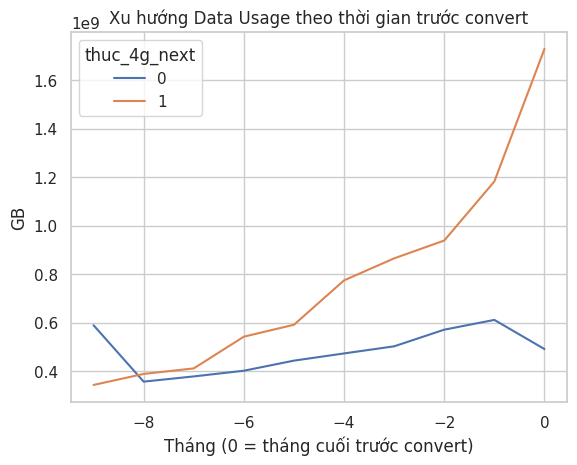

In [ ]:
# Với nhóm convert (thuc_4g_next == 1): tháng cuối cùng trong df_model là T-0 (tháng ngay trước convert)
# Nhóm không convert: lấy tháng cuối cùng làm mốc tương tự

# Tính rank thời gian ngược (0 = tháng gần nhất, -1 = trước đó 1 tháng...)
df_model['month_rank'] = (
    df_model.groupby('user_id')['date']
    .rank(method='dense', ascending=False)
    .astype(int)
    .mul(-1)
    .add(1)  # 0 = tháng cuối, -1 = trước đó...
)

# Plot trung bình data usage theo month_rank, chia theo nhóm
trend = (
    df_model.groupby(['month_rank', 'thuc_4g_next'])['tong_ll_gprs']
    .mean()
    .reset_index()
)

sns.lineplot(data=trend, x='month_rank', y='tong_ll_gprs', hue='thuc_4g_next')
plt.title("Xu hướng Data Usage theo thời gian trước convert")
plt.xlabel("Tháng (0 = tháng cuối trước convert)")
plt.ylabel("GB")
plt.show()

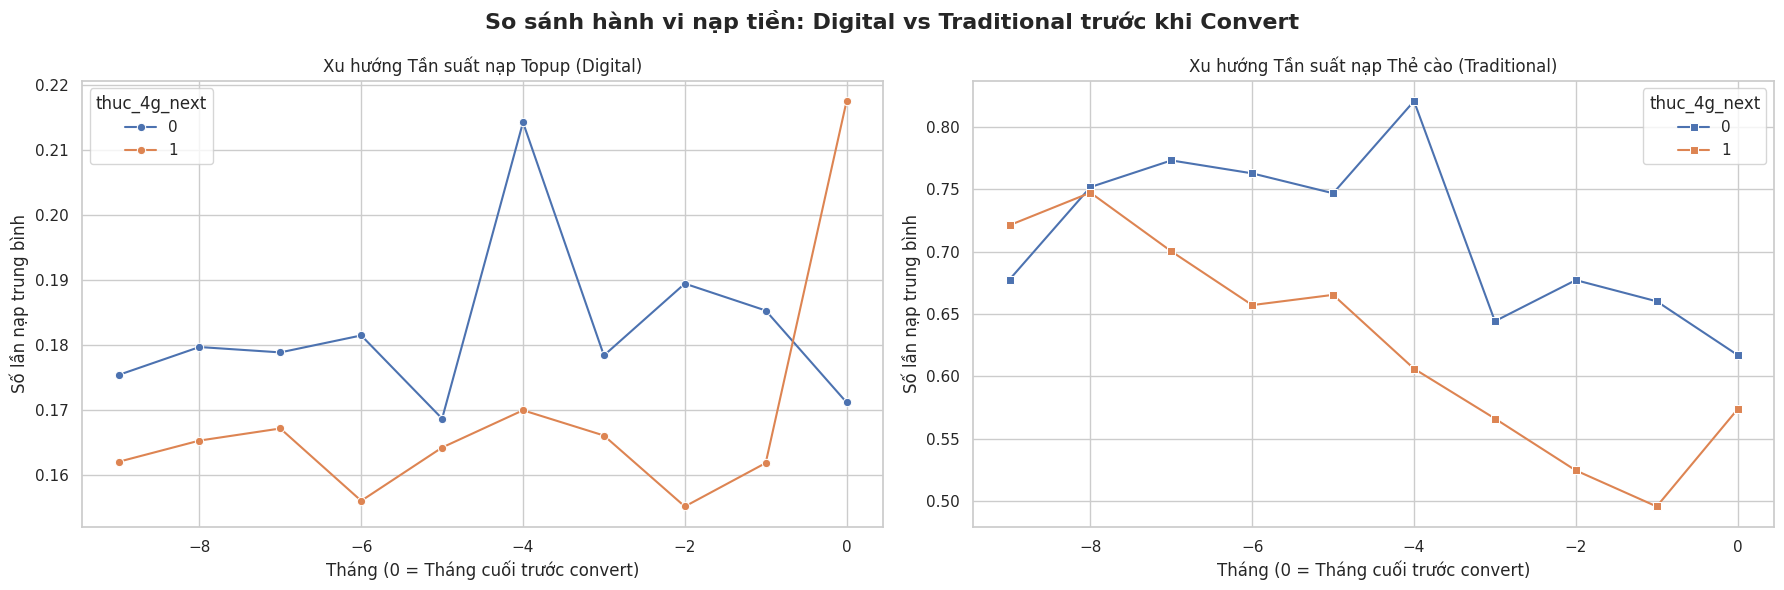

Thống kê tại tháng cuối cùng trước khi Convert (Month Rank 0):


,so_lan_nap_topup,so_lan_nap_the
thuc_4g_next,,
0,0.171159,0.617123
1,0.217499,0.573629


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo lưới 2x2 để so sánh trực quan
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Xu hướng Số lần nạp Topup (Digital)
trend_topup_count = df_model.groupby(['month_rank', 'thuc_4g_next'])['so_lan_nap_topup'].mean().reset_index()
sns.lineplot(data=trend_topup_count, x='month_rank', y='so_lan_nap_topup', hue='thuc_4g_next', marker='o', ax=axes[0])
axes[0].set_title("Xu hướng Tần suất nạp Topup (Digital)")
axes[0].set_xlabel("Tháng (0 = Tháng cuối trước convert)")
axes[0].set_ylabel("Số lần nạp trung bình")

# 2. Xu hướng Số lần nạp Thẻ (Traditional)
trend_card_count = df_model.groupby(['month_rank', 'thuc_4g_next'])['so_lan_nap_the'].mean().reset_index()
sns.lineplot(data=trend_card_count, x='month_rank', y='so_lan_nap_the', hue='thuc_4g_next', marker='s', ax=axes[1])
axes[1].set_title("Xu hướng Tần suất nạp Thẻ cào (Traditional)")
axes[1].set_xlabel("Tháng (0 = Tháng cuối trước convert)")
axes[1].set_ylabel("Số lần nạp trung bình")

plt.suptitle("So sánh hành vi nạp tiền: Digital vs Traditional trước khi Convert", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Tính toán con số cụ thể tại tháng cuối (Month Rank 0)
last_month_stats = df_model[df_model['month_rank'] == 0].groupby('thuc_4g_next')[['so_lan_nap_topup', 'so_lan_nap_the']].mean()
print("Thống kê tại tháng cuối cùng trước khi Convert (Month Rank 0):")
display(last_month_stats)

- Nhóm người dùng chuyển đổi có xu hướng sử dụng data nhiều, và ở các tháng gần với tháng convert, nhu cầu sử dụng data của nhóm khách hàng này có xu hướng tăng dần rõ rệt theo tháng
- Ở nhóm khách hàng không convert, nhu cầu sử dụng data của nhóm khách hàng này giữ ở mức ổn định
-> Có thể nhu cầu sử dụng data tăng cao là dấu hiệu cho việc khách hàng convert sang 4g

Người dùng có nạp tiền/ chi tiêu nhiều hơn trước khi convert không

Tần suất nạp tiền và thời gian sử dụng có nhiều hơn trước khi convert không

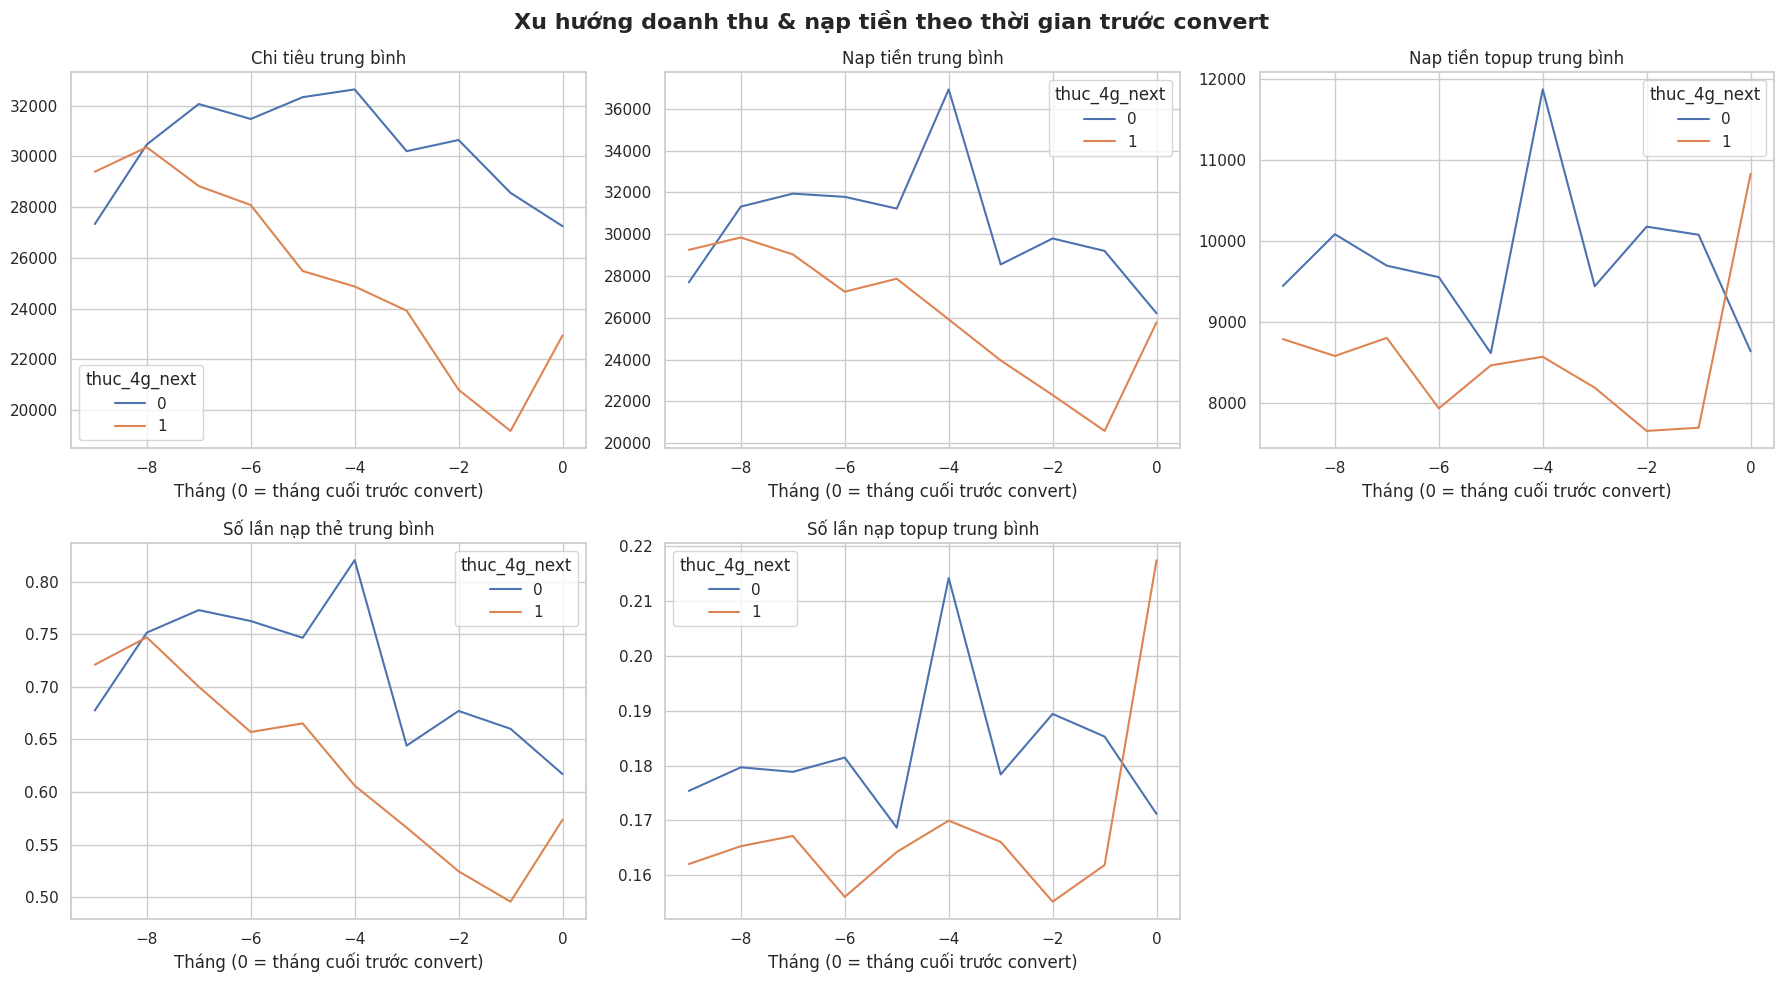

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo lưới 2x3 (để chứa đủ 5 biểu đồ, sẽ có 6 ô)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ('tong_cuoc_goc_fn', 'Chi tiêu trung bình'),
    ('tong_tien_nap_the', 'Nap tiền trung bình'),
    ('tong_tien_nap_topup', 'Nap tiền topup trung bình'),
    ('so_lan_nap_the', 'Số lần nạp thẻ trung bình'),
    ('so_lan_nap_topup','Số lần nạp topup trung bình')
]

axes_flat = axes.flatten()

# Vẽ 5 biểu đồ
for i, (col, title) in enumerate(metrics):
    trend = (
        df_model
        .groupby(['month_rank', 'thuc_4g_next'])[col]
        .mean()
        .reset_index()
    )
    sns.lineplot(
        data=trend,
        x='month_rank',
        y=col,
        hue='thuc_4g_next',
        ax=axes_flat[i]
    )
    axes_flat[i].set_title(title)
    axes_flat[i].set_xlabel("Tháng (0 = tháng cuối trước convert)")
    axes_flat[i].set_ylabel("")
    axes_flat[i].legend(title='thuc_4g_next')

# Xóa subplot thứ 6 không sử dụng (axes[1, 2])
fig.delaxes(axes[1, 2])

plt.suptitle("Xu hướng doanh thu & nạp tiền theo thời gian trước convert", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Xem xét xu hướng doanh thu & nạp tiền theo thời gian trước convert:

- Chi tiêu trung bình:

Nhóm không convert có chi tiêu cao hơn và giao động trong 30,000 đến 33,000 nhưng có xu hướng giảm dần về cuối.
Nhóm convert chi tiêu thấp hơn trong suốt giai đoạn quan sát nhưng tăng đột biến mạnh ở tháng cuối (xấp xỉ 23,000) gợi ý rằng việc chuyển đổi 4G đi kèm với việc chi tiêu nhiều hơn cho dịch vụ.

- Nạp thẻ trung bình:

Tương tự chi tiêu, nhóm không convert nạp tiền nhiều hơn và ổn định hơn.
Nhóm convert có mức nạp thấp hơn nhưng **tăng mạnh ở tháng cuối , cho thấy KH nạp tiền để chuẩn bị cho việc chuyển đổi hoặc đăng ký gói 4G.

- Tần suất nạp thẻ:

Nhóm không convert tần suất nạp ổn định và cao hơn nhóm convert, tuy nhiên vào tháng cuối cùng nhóm convert có xu hướng tăng mạnh tần suất nạp và áp đảo nhóm không convert

- Hình thức topup:

Phản ứng của nhóm sử dụng dịch vụ topup có thể thấy mạnh hơn đáng kể so với bình thường, độ dốc lên vào cuối tháng cho thấy sự tăng đột biến và vượt lên hoàn toàn so với nhóm ko chuyển đổi ở cả tần suất lẫn chi tiêu => nhóm sử dụng dịch vụ hiện đại phản ứng mạnh hơn

### Nhận xét
Hiệu ứng 'Điểm bùng phát' (The Surging Point): Mặc dù nhóm không convert có nền tảng chi tiêu cao và ổn định hơn, nhưng nhóm convert lại sở hữu một 'điểm rơi' cực kỳ mạnh mẽ. Việc chi tiêu và nạp thẻ tăng đột biến ở tháng cuối cùng (T-0) cho thấy hành vi chuyển đổi không phải là một quá trình từ từ, mà là một quyết định bộc phát đi kèm với việc chuẩn bị tài chính (nạp tiền) để nâng cấp gói cước ngay lập tức.

Sự trỗi dậy của nhóm 'Modern Users' (Topup): Insight quan trọng nhất nằm ở hình thức Topup. Nhóm convert không chỉ tăng dần mà còn vượt mặt hoàn toàn nhóm không convert ở tháng cuối. Điều này khẳng định nhóm khách hàng sử dụng dịch vụ số (digital-savvy) chính là động lực chuyển đổi chính. Họ phản ứng nhanh hơn và quyết liệt hơn với công nghệ mới.

Mâu thuẫn về lòng trung thành (Spending vs. Conversion): Việc nhóm không convert có chi tiêu cao nhưng ổn định/giảm dần cho thấy họ là những khách hàng cũ, có thói quen sử dụng cố định (có thể là thoại) và ít bị tác động bởi công nghệ. Ngược lại, nhóm convert dù có xuất phát điểm thấp hơn nhưng lại là nhóm có tiềm năng tăng trưởng doanh thu (incremental revenue) rất lớn khi họ sẵn sàng 'đốt cháy' giai đoạn ở tháng cuối.

Người chỉ gọi thoại hay người dùng data nhiều sẽ có kha năng convert cao hơn

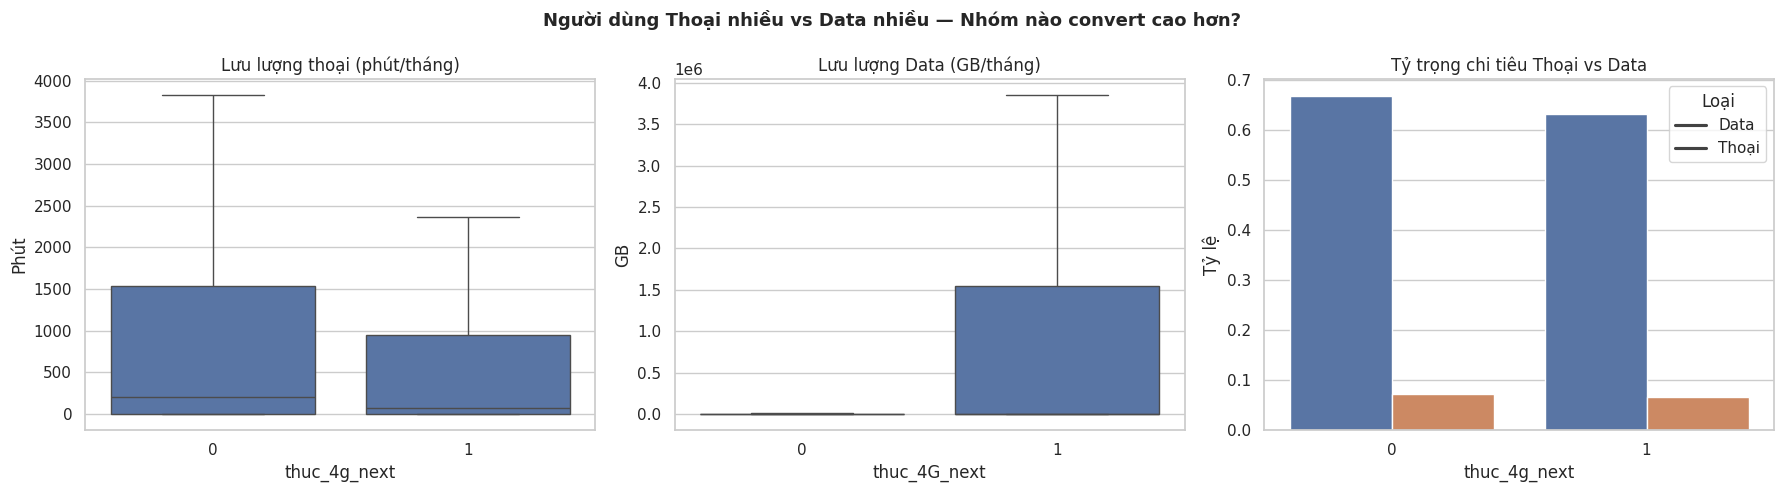

              ll_thoai  tong_ll_gprs  ratio_thoai  ratio_data
thuc_4g_next                                                 
0                206.0           0.0     0.879336         0.0
1                 74.0           0.0     0.839623         0.0


In [ ]:
#tỷ lệ chi tiêu thoại/ tổng chi tiêu
df_model['ratio_thoai'] = (
    df_model['tong_cuoc_goc_thoai'] / df_model['tong_cuoc_goc_fn'].replace(0, np.nan)
)
df_model['ratio_data'] = (
    df_model['tong_cuoc_goc_data_4_huong'] / df_model['tong_cuoc_goc_fn'].replace(0, np.nan)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#lưu lượng thoại
sns.boxplot(
    data=df_model,
    x='thuc_4g_next',
    y='ll_thoai',
    ax=axes[0],
    showfliers=False
)
axes[0].set_title("Lưu lượng thoại (phút/tháng)")
axes[0].set_xlabel("thuc_4g_next")
axes[0].set_ylabel("Phút")
#lưu lượng data
sns.boxplot(
    data=df_model,
    x='thuc_4g_next',
    y='tong_ll_gprs',
    ax=axes[1],
    showfliers=False
)
axes[1].set_title("Lưu lượng Data (GB/tháng)")
axes[1].set_xlabel("thuc_4G_next")
axes[1].set_ylabel("GB")

#tỷ trọng chi tiêu thoại và data
ratio = (
    df_model
    .groupby('thuc_4g_next')[['ratio_thoai', 'ratio_data']]
    .mean()
    .reset_index()
    .melt(id_vars='thuc_4g_next', var_name='loai', value_name='ty_trong')
)

sns.barplot(
    data=ratio,
    x='thuc_4g_next',
    y='ty_trong',
    hue='loai',
    ax=axes[2]
)
axes[2].set_title("Tỷ trọng chi tiêu Thoại vs Data")
axes[2].set_xlabel("thuc_4g_next")
axes[2].set_ylabel("Tỷ lệ")
axes[2].legend(title='Loại', labels=['Data', 'Thoại'])

plt.suptitle("Người dùng Thoại nhiều vs Data nhiều — Nhóm nào convert cao hơn?",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Thống kê tóm tắt
print(df_model.groupby('thuc_4g_next')[['ll_thoai', 'tong_ll_gprs', 'ratio_thoai', 'ratio_data']].median())

Nhóm không convert có lưu lượng thoại cao hơn đáng kể median ~1,300 phút/tháng so với nhóm convert chỉ ~300 phút/tháng.

Ngược lại với nhóm convert sử dụng data cao hơn rõ rệt so với nhóm không convert gần như bằng 0, giống như ở phân tích trước.

Tỉ thuê bao chi tiêu trong nhóm chuyển đổi thoại cũng chiếm phần nhỏ so với data

=>Người dùng thoại nhiều ít có xu hướng convert lên 4G

Phân khúc bằng RFM để xác định:
- Nhóm khách hàng nào sẽ có tỷ lệ convert cao hơn
- Liệu nhóm khách hàng high-value sẽ có khả năng convert cao hơn không ?

In [ ]:
# rfm segmentation
df_rfm = (
    df_model
    .groupby('user_id')
    .agg(
        R=('so_ngay_su_dung','mean'),
        F=('so_lan_nap_the','sum'),
        M=('tong_cuoc_goc_fn','mean'),
        thuc_4g_next=('thuc_4g_next','max')
    )
    .reset_index()
)

for col in ['R', 'F', 'M']:
    df_rfm[f'{col}_score'] = pd.qcut(
        df_rfm[col].rank(method='first'),  # rank trước để phá duplicate
        q=4,
        labels=[1, 2, 3, 4]
    ).astype(int)

df_rfm['rfm_score'] = df_rfm['R_score'] + df_rfm['F_score'] + df_rfm['M_score']

def segment_rfm(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'Potential'
    else:
        return 'At Risk'

df_rfm['segment'] = df_rfm['rfm_score'].apply(segment_rfm)

print(df_rfm['segment'].value_counts())
print("\nConvert rate theo segment:")
print(df_rfm.groupby('segment')['thuc_4g_next'].mean().sort_values(ascending=False))

segment
Potential    43042
Loyal        32024
Champions    31953
At Risk      27169
Name: count, dtype: int64

Convert rate theo segment:
segment
Potential    0.665629
Loyal        0.574101
At Risk      0.394162
Champions    0.377711
Name: thuc_4g_next, dtype: float64


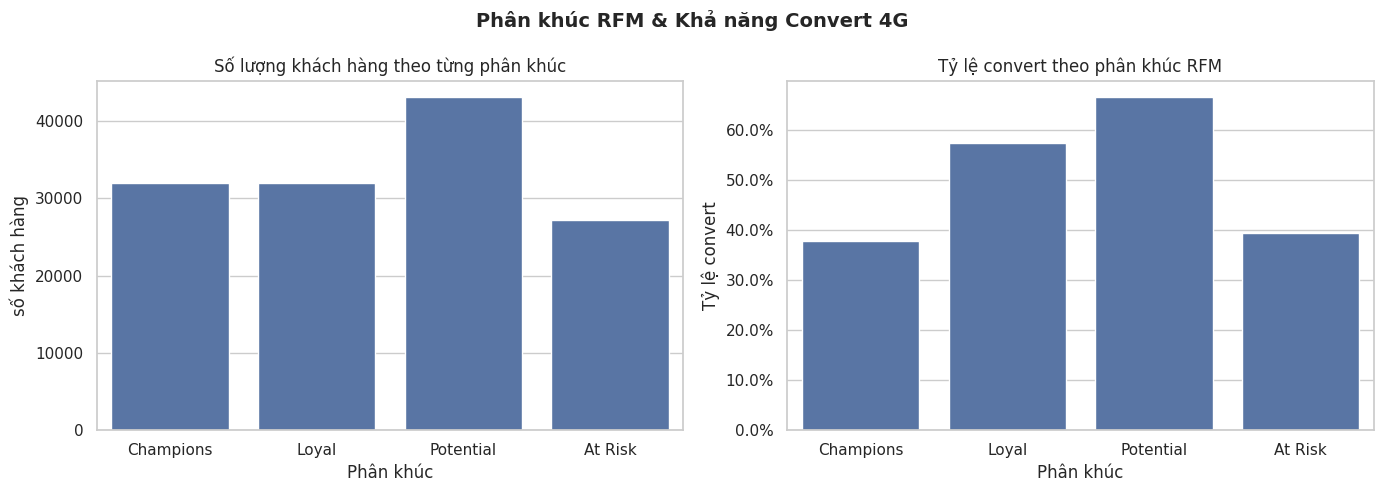

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_count = df_rfm['segment'].value_counts().reset_index()
segment_count.columns = ['Segment', 'Count']

sns.barplot(
    data=segment_count, x='Segment', y='Count',
    order=['Champions','Loyal','Potential','At Risk'],
    ax = axes[0])
axes[0].set_title("Số lượng khách hàng theo từng phân khúc")
axes[0].set_xlabel("Phân khúc")
axes[0].set_ylabel("số khách hàng")

#tỷ lệ convert theo segment

convert_rate = (
    df_rfm
    .groupby('segment')['thuc_4g_next']
    .mean()
    .reset_index()
    .rename(columns={'thuc_4g_next': 'convert_rate'})
)

sns.barplot(
    data=convert_rate, x='segment', y='convert_rate',
    order=['Champions','Loyal','Potential','At Risk'],
    ax = axes[1]
)

axes[1].set_title("Tỷ lệ convert theo phân khúc RFM")
axes[1].set_xlabel("Phân khúc")
axes[1].set_ylabel("Tỷ lệ convert")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

plt.suptitle("Phân khúc RFM & Khả năng Convert 4G", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_rfm.groupby('segment')[['R','F','M', 'rfm_score','thuc_4g_next']].mean().round(2).sort_values('rfm_score', ascending=False)

,R,F,M,rfm_score,thuc_4g_next
segment,,,,,
Champions,23.78,14.71,84524.37,10.72,0.38
Loyal,19.57,4.13,19984.36,8.39,0.57
Potential,20.75,0.97,4751.53,6.55,0.67
At Risk,7.52,0.19,1148.55,4.17,0.39


Nhận xét kết quả phân khúc RFM:

Qua phân tích cho thấy, không phải nhóm khách hàn high value là nhóm có khả năng convert cao nhất:
- Potential (66.5%) có tỷ lệ convert cao nhất, dù chi tiêu trung bình chỉ ở mức 4751 và số ngày active trung bình khoảng 21 ngày/tháng.
- Loyal (57%) convert cao thứ 2, chi tiêu trung bình gần 20,000 VNĐ, active đều đặn. Đây là nhóm có nền tảng sử dụng tốt và bắt đầu có nhu cầu nâng cấp trải nghiệm.
- Champions (38%) — dù chi tiêu cao nhất 84,000 và active nhiều nhất 24 ngày/tháng, tỷ lệ convert lại thấp hơn Potential và Loyal. Có thể nhóm này đã tối ưu hóa chi tiêu trên hạ tầng cũ và chưa cảm thấy cần thiết phải chuyển đổi.
- At Risk (39%) — tỷ lệ convert thấp nhất, ít active trung bình 8 ngày/tháng và chi tiêu thấp 1,148 VNĐ, nhóm này thiếu cả nhu cầu lẫn động lực chuyển đổi.

### Deep Dive: Tại sao nhóm 'Potential' lại có tỷ lệ Convert cao nhất?
Tiến hành phân tích sâu hơn các chỉ số về Hành vi số (Digital behavior) và Đặc điểm nhân khẩu học để chứng minh insight này.

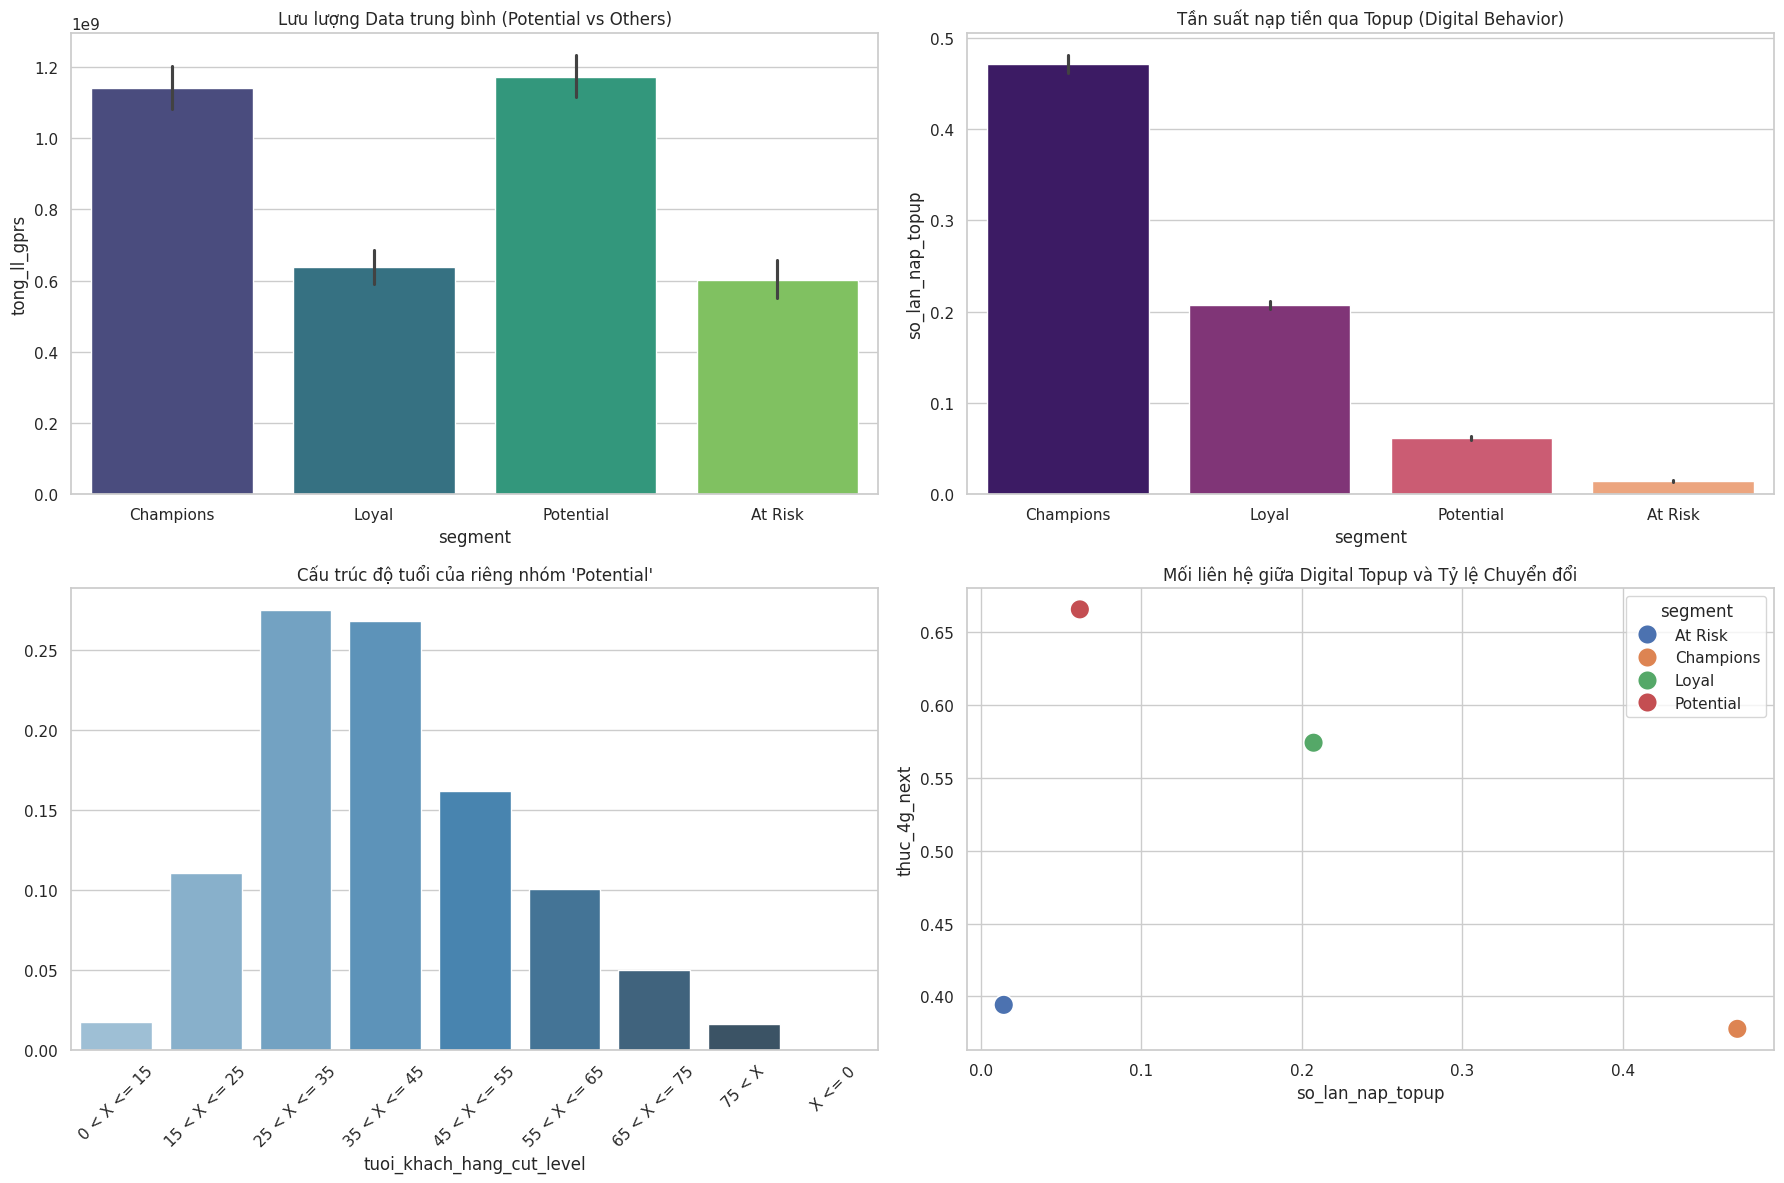

,thuc_4g_next,tong_ll_gprs,so_lan_nap_topup,tong_tien_nap_topup
segment,,,,
Potential,0.666,1.171221e+09,0.062,2547.515
Loyal,0.574,6.383923e+08,0.207,8711.787
At Risk,0.394,6.018293e+08,0.014,455.285
Champions,0.378,1.140554e+09,0.471,27453.285


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chuẩn bị dữ liệu merge giữa RFM và các đặc trưng hành vi
df_insight = pd.merge(
    df_rfm[['user_id', 'segment', 'thuc_4g_next']],
    df_model.groupby('user_id').agg({
        'tong_ll_gprs': 'mean',
        'tong_tien_nap_topup': 'mean',
        'so_lan_nap_topup': 'mean',
        'tuoi_khach_hang_cut_level': 'last'
    }).reset_index(),
    on='user_id'
)

# Tính toán tỷ lệ đóng góp của Topup trong tổng nạp (nếu cần) hoặc số lần nạp Digital
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Lưu lượng Data trung bình theo Segment
sns.barplot(data=df_insight, x='segment', y='tong_ll_gprs', ax=axes[0, 0],
            order=['Champions', 'Loyal', 'Potential', 'At Risk'], palette='viridis')
axes[0, 0].set_title("Lưu lượng Data trung bình (Potential vs Others)")

# 2. Tần suất nạp Topup (Digital Savvy Check)
sns.barplot(data=df_insight, x='segment', y='so_lan_nap_topup', ax=axes[0, 1],
            order=['Champions', 'Loyal', 'Potential', 'At Risk'], palette='magma')
axes[0, 1].set_title("Tần suất nạp tiền qua Topup (Digital Behavior)")

# 3. Phân bổ độ tuổi trong nhóm Potential
potential_age = df_insight[df_insight['segment'] == 'Potential']['tuoi_khach_hang_cut_level'].value_counts(normalize=True).sort_index()
sns.barplot(x=potential_age.index, y=potential_age.values, ax=axes[1, 0], palette='Blues_d')
axes[1, 0].set_title("Cấu trúc độ tuổi của riêng nhóm 'Potential'")
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Tương quan giữa nạp Topup và Tỷ lệ Convert
sns.scatterplot(data=df_insight.groupby('segment').agg({'so_lan_nap_topup':'mean', 'thuc_4g_next':'mean'}).reset_index(),
                x='so_lan_nap_topup', y='thuc_4g_next', hue='segment', s=200, ax=axes[1, 1])
axes[1, 1].set_title("Mối liên hệ giữa Digital Topup và Tỷ lệ Chuyển đổi")

plt.tight_layout()
plt.show()

# Hiển thị bảng số liệu chứng minh
summary_insight = df_insight.groupby('segment').agg({
    'thuc_4g_next': 'mean',
    'tong_ll_gprs': 'mean',
    'so_lan_nap_topup': 'mean',
    'tong_tien_nap_topup': 'mean'
}).round(3).sort_values('thuc_4g_next', ascending=False)

display(summary_insight)

1. Hành vi Data: Mặc dù chi tiêu (Monetary) thấp hơn nhóm Champions, nhưng lưu lượng Data trung bình của nhóm Potential đạt xấp xỉ 1.17 GB, tương đương với nhóm Champions. Điều này chứng tỏ họ có nhu cầu sử dụng 4G rất thực tế.
2. Độ tuổi: Nhóm này tập trung mạnh ở độ tuổi 25-45, là nhóm khách hàng trẻ, dễ thích nghi với công nghệ mới.
3. Hiệu quả: Tỷ lệ chuyển đổi của nhóm Potential đạt tới 66.6%, cao nhất trong tất cả các phân khúc, biến đây thành mục tiêu trọng tâm cho các chiến dịch marketing nâng cấp lên 4G.

### So sánh sâu: Nhóm 'Potential' vs 'Loyal'
Để tối ưu hóa chiến lược, ta cần phân biệt rõ:
- **Potential:** Nhóm 'ngòi nổ' - Chi tiêu thấp nhưng nhu cầu data bùng phát mạnh.
- **Loyal:** Nhóm 'bền vững' - Chi tiêu khá, trung thành, cần cú hích để nâng cấp trải nghiệm.

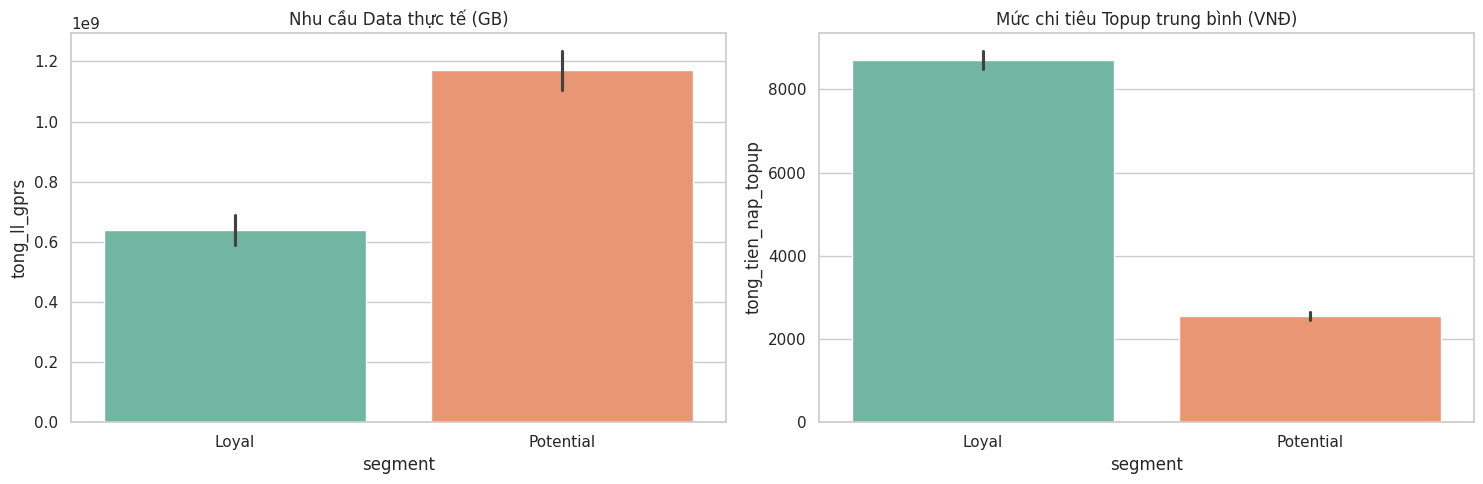

,segment,thuc_4g_next,tong_ll_gprs,tong_tien_nap_topup,so_lan_nap_topup
0,Loyal,0.574101,6.383923e+08,8711.787077,0.207275
1,Potential,0.665629,1.171221e+09,2547.515145,0.061604


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Lọc lấy 2 nhóm mục tiêu
df_target_compare = df_insight[df_insight['segment'].isin(['Potential', 'Loyal'])]

# Tính toán bảng so sánh
loyal_vs_potential = df_target_compare.groupby('segment').agg({
    'thuc_4g_next': 'mean',
    'tong_ll_gprs': 'mean',
    'tong_tien_nap_topup': 'mean',
    'so_lan_nap_topup': 'mean'
}).reset_index()

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=df_target_compare, x='segment', y='tong_ll_gprs', ax=axes[0], palette='Set2')
axes[0].set_title("Nhu cầu Data thực tế (GB)")

sns.barplot(data=df_target_compare, x='segment', y='tong_tien_nap_topup', ax=axes[1], palette='Set2')
axes[1].set_title("Mức chi tiêu Topup trung bình (VNĐ)")

plt.tight_layout()
plt.show()

display(loyal_vs_potential)

**Nhận xét làm rõ nhóm Loyal:**
- **Loyal** có mức chi tiêu Digital (Topup) cao gấp 3.5 lần so với Potential (~8,700 vs ~2,500).
- Tuy nhiên, lưu lượng Data của họ lại thấp hơn Potential (~0.6 GB vs ~1.1 GB).
- **Insight:** Nhóm Loyal là những người dùng có tiền, có thói quen dùng dịch vụ số nhưng chưa dùng nhiều Data. Họ cần các gói cước 4G đi kèm nội dung giải trí (Video, Social) để kích cầu sử dụng.

### So sánh Nhân khẩu học: Potential vs Loyal

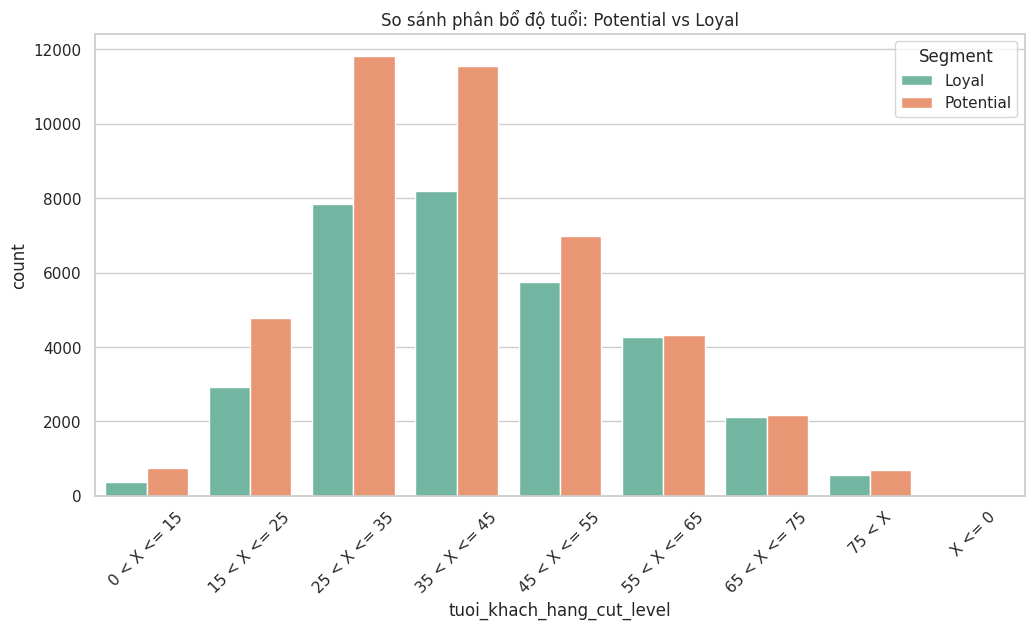

segment,Loyal,Potential
tuoi_khach_hang_cut_level,,
0 < X <= 15,1.17,1.72
15 < X <= 25,9.17,11.08
25 < X <= 35,24.46,27.48
35 < X <= 45,25.55,26.84
45 < X <= 55,17.96,16.21
55 < X <= 65,13.33,10.03
65 < X <= 75,6.61,5.02
75 < X,1.75,1.59
X <= 0,0.01,0.02


In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_target_compare,
    x='tuoi_khach_hang_cut_level',
    hue='segment',
    order=sorted(df_target_compare['tuoi_khach_hang_cut_level'].unique()),
    palette='Set2'
)
plt.title("So sánh phân bổ độ tuổi: Potential vs Loyal")
plt.xticks(rotation=45)
plt.legend(title='Segment')
plt.show()

# Tính tỷ lệ % theo độ tuổi cho từng segment
age_dist = pd.crosstab(df_target_compare['tuoi_khach_hang_cut_level'], df_target_compare['segment'], normalize='columns') * 100
display(age_dist.round(2))

**Đặc điểm nhân khẩu học làm rõ nhóm Loyal:**
- Nhóm **Loyal** thường có tỷ trọng khách hàng ở độ tuổi **35-55** cao hơn so với Potential.
- Đây là nhóm khách hàng trung niên, có thu nhập ổn định (chi tiêu cao) nhưng thói quen sử dụng data chưa cao bằng nhóm trẻ 25-35.
- **Kết luận:** Chiến dịch cho Loyal cần tập trung vào việc hướng dẫn họ cách tiêu dùng data (giáo dục thị trường) thông qua các dịch vụ tiện ích, thay vì chỉ tập trung vào tốc độ như nhóm Potential.

### TỔNG KẾT: CHÂN DUNG KHÁCH HÀNG TIỀM NĂNG CHUYỂN ĐỔI 4G

Qua các bước phân tích, chúng ta có thể phác họa chân dung nhóm khách hàng có khả năng convert cao nhất như sau:

#### 1. Đặc điểm nhân khẩu học & Hạ tầng
*   **Độ tuổi:** Tập trung mạnh ở nhóm trẻ và trung lưu (**25 - 45 tuổi**).
*   **Hạ tầng kỹ thuật:** Đã sở hữu **SIM 4G** và **Thiết bị 4G/5G** nhưng chưa chuyển đổi (thường do thói quen hoặc rào cản sóng cục bộ).

#### 2. Phân khúc mục tiêu (RFM Insights)
*   **Nhóm Potential (Ngòi nổ):** Chi tiêu thấp nhưng nhu cầu Data cao (~1.17 GB). Đây là nhóm có tỷ lệ chuyển đổi cao nhất (**66.6%**).
*   **Nhóm Loyal (Bền vững):** Chi tiêu cao, có thói quen dùng dịch vụ số (Topup cao gấp 3.5 lần Potential) nhưng dùng Data ít hơn. Đây là nhóm cần được 'giáo dục' về tiện ích Data.

#### 3. Hành vi & Điểm bùng phát (The Surging Point)
*   **Tín hiệu Data:** Lưu lượng Data không tăng đều mà thường có xu hướng bùng phát mạnh ngay trước khi chuyển đổi.
*   **Tín hiệu Nạp tiền (Digital Trigger):** Sự gia tăng đột ngột về **Tần suất nạp Topup** (kênh số) trong tháng gần nhất (T-0) là chỉ báo quan trọng nhất. Họ nạp tiền để chuẩn bị nâng cấp gói cước ngay lập tức.
*   **Hoạt động:** Nhóm convert active trung bình **21-23 ngày/tháng**, cao hơn hẳn nhóm không convert (~13 ngày).

#### 4. Chiến lược tiếp cận đề xuất
*   **Ưu tiên:** Đẩy mạnh chiến dịch vào nhóm **Potential** bằng các gói Data lớn, giá rẻ.
*   **Kích cầu:** Gửi ưu đãi gói 4G kèm nội dung (Video/Social) cho nhóm **Loyal**.
*   **Thời điểm:** Real-time trigger ngay khi hệ thống ghi nhận một user có lượt nạp Topup tăng bất thường so với trung bình 3 tháng trước đó.